In [ ]:
# Cell 1: Install dependencies and confirm GPU
!pip install -q transformers datasets accelerate scikit-learn pandas numpy imbalanced-learn

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

GPU available: True
Device: Tesla T4


In [ ]:
# Cell 2: Mount Google Drive and set up the project folder
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/CareerLens_Capstone_C'
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
print("Project folder ready at:", PROJECT_DIR)

Mounted at /content/drive
Project folder ready at: /content/drive/MyDrive/CareerLens_Capstone_C


In [ ]:
# Cell 3: Load the dataset from Hugging Face
from datasets import load_dataset

dataset = load_dataset("cnamuangtoun/resume-job-description-fit")
print(dataset)

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())
train_df.head(2)

train.csv: reconstructing file:   0%|          |  0.00B / 53.4MB            

train.csv: downloading bytes:           |  0.00B            

test.csv: reconstructing file:   0%|          |  0.00B / 15.2MB            

test.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6241 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1759 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 6241
    })
    test: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 1759
    })
})

Train shape: (6241, 3)
Test shape: (1759, 3)

Columns: ['resume_text', 'job_description_text', 'label']


,resume_text,job_description_text,label
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit


In [ ]:
# Cell 4: Save raw train/test data to Drive (backup, so re-download isn't needed)
train_df.to_csv(f'{PROJECT_DIR}/data/raw_train.csv', index=False)
test_df.to_csv(f'{PROJECT_DIR}/data/raw_test.csv', index=False)
print("Saved raw_train.csv and raw_test.csv to:", f'{PROJECT_DIR}/data')

Saved raw_train.csv and raw_test.csv to: /content/drive/MyDrive/CareerLens_Capstone_C/data


In [ ]:
# Cell 5: Audit the dataset (resumable — reloads from Drive if already computed)
import hashlib
import pandas as pd

audit_path = f'{PROJECT_DIR}/data/hashed_combined.csv'

if os.path.exists(audit_path):
    print("Found existing hashed data — loading from Drive instead of recomputing.")
    df = pd.read_csv(audit_path)
else:
    train_df["orig_split"] = "train"
    test_df["orig_split"] = "test"
    df = pd.concat([train_df, test_df], ignore_index=True)

    def text_hash(text):
        return hashlib.md5(str(text).strip().encode("utf-8")).hexdigest()

    df["resume_id"] = df["resume_text"].apply(text_hash)
    df["jd_id"] = df["job_description_text"].apply(text_hash)

    df.to_csv(audit_path, index=False)
    print("Computed hashes and saved to Drive:", audit_path)

# --- Audit stats ---
print(f"\nTotal rows: {len(df)}")
print(f"Unique resumes: {df['resume_id'].nunique()}")
print(f"Unique job descriptions: {df['jd_id'].nunique()}")

orig_train_resumes = set(df.loc[df.orig_split == "train", "resume_id"])
orig_test_resumes = set(df.loc[df.orig_split == "test", "resume_id"])
overlap = orig_train_resumes & orig_test_resumes
print(f"\nResumes shared between ORIGINAL train/test: {len(overlap)} "
      f"({len(overlap)/len(orig_test_resumes):.1%} of test resumes)")

print("\nLabel distribution (overall):")
print(df["label"].value_counts(normalize=True))

Computed hashes and saved to Drive: /content/drive/MyDrive/CareerLens_Capstone_C/data/hashed_combined.csv

Total rows: 8000
Unique resumes: 643
Unique job descriptions: 351

Resumes shared between ORIGINAL train/test: 476 (99.8% of test resumes)

Label distribution (overall):
label
No Fit           0.50
Potential Fit    0.25
Good Fit         0.25
Name: proportion, dtype: float64


In [ ]:
# Cell 6: Drop exact duplicate rows, flag conflicting labels (resumable)
dedup_path = f'{PROJECT_DIR}/data/deduped.csv'
conflict_path = f'{PROJECT_DIR}/data/label_conflicts.csv'

if os.path.exists(dedup_path):
    print("Found existing deduped data — loading from Drive.")
    df_clean = pd.read_csv(dedup_path)
else:
    before = len(df)
    df_clean = df.drop_duplicates(subset=["resume_id", "jd_id", "label"]).reset_index(drop=True)
    print(f"Dropped {before - len(df_clean)} exact duplicate rows "
          f"({before} -> {len(df_clean)})")

    # Flag same resume+jd pair with DIFFERENT labels (noisy/ambiguous)
    conflict_mask = df_clean.duplicated(subset=["resume_id", "jd_id"], keep=False)
    n_conflict_pairs = df_clean.loc[conflict_mask, ["resume_id", "jd_id"]].drop_duplicates().shape[0]
    print(f"Resume-JD pairs with conflicting labels: {n_conflict_pairs}")

    if n_conflict_pairs:
        df_clean[conflict_mask].sort_values(["resume_id", "jd_id"]).to_csv(conflict_path, index=False)
        print("  -> saved to:", conflict_path)

    df_clean.to_csv(dedup_path, index=False)
    print("Saved deduped data to:", dedup_path)

print(f"\nFinal row count: {len(df_clean)}")
print(f"Unique resumes: {df_clean['resume_id'].nunique()}")
print(f"Unique job descriptions: {df_clean['jd_id'].nunique()}")
print("\nLabel distribution after dedup:")
print(df_clean["label"].value_counts(normalize=True))

Dropped 1 exact duplicate rows (8000 -> 7999)
Resume-JD pairs with conflicting labels: 6
  -> saved to: /content/drive/MyDrive/CareerLens_Capstone_C/data/label_conflicts.csv
Saved deduped data to: /content/drive/MyDrive/CareerLens_Capstone_C/data/deduped.csv

Final row count: 7999
Unique resumes: 643
Unique job descriptions: 351

Label distribution after dedup:
label
No Fit           0.499937
Potential Fit    0.250031
Good Fit         0.250031
Name: proportion, dtype: float64


In [ ]:
# Cell 7: Group-stratified split by resume_id — no resume crosses splits (resumable)
from sklearn.model_selection import StratifiedGroupKFold

train_path = f'{PROJECT_DIR}/data/train_clean.csv'
val_path = f'{PROJECT_DIR}/data/val_clean.csv'
test_path = f'{PROJECT_DIR}/data/test_clean.csv'

if os.path.exists(train_path) and os.path.exists(val_path) and os.path.exists(test_path):
    print("Found existing clean splits — loading from Drive.")
    train_clean = pd.read_csv(train_path)
    val_clean = pd.read_csv(val_path)
    test_clean = pd.read_csv(test_path)
else:
    SEED = 42

    # Step 1: split off ~15% as test (7 folds ~ 14.3% each)
    sgkf1 = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)
    trainval_idx, test_idx = next(sgkf1.split(df_clean, df_clean["label"], df_clean["resume_id"]))
    trainval_df = df_clean.iloc[trainval_idx].reset_index(drop=True)
    test_clean = df_clean.iloc[test_idx].reset_index(drop=True)

    # Step 2: split remaining ~85% into train/val (6 folds ~ 16.7% each -> ~15% of original)
    sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED)
    train_idx, val_idx = next(sgkf2.split(trainval_df, trainval_df["label"], trainval_df["resume_id"]))
    train_clean = trainval_df.iloc[train_idx].reset_index(drop=True)
    val_clean = trainval_df.iloc[val_idx].reset_index(drop=True)

    train_clean.to_csv(train_path, index=False)
    val_clean.to_csv(val_path, index=False)
    test_clean.to_csv(test_path, index=False)
    print("Computed new splits and saved to Drive.")

# --- Sanity check: zero resume-level leakage ---
tr_r, va_r, te_r = set(train_clean.resume_id), set(val_clean.resume_id), set(test_clean.resume_id)
assert not (tr_r & va_r), "Leakage between train and val!"
assert not (tr_r & te_r), "Leakage between train and test!"
assert not (va_r & te_r), "Leakage between val and test!"
print("No resume-level leakage across splits — verified\n")

print(f"Train: {len(train_clean)}  Val: {len(val_clean)}  Test: {len(test_clean)}")
print("\nTrain label dist:\n", train_clean["label"].value_counts(normalize=True))
print("\nVal label dist:\n", val_clean["label"].value_counts(normalize=True))
print("\nTest label dist:\n", test_clean["label"].value_counts(normalize=True))

Computed new splits and saved to Drive.
No resume-level leakage across splits — verified

Train: 5832  Val: 1156  Test: 1011

Train label dist:
 label
No Fit           0.488340
Good Fit         0.259088
Potential Fit    0.252572
Name: proportion, dtype: float64

Val label dist:
 label
No Fit           0.523356
Potential Fit    0.263841
Good Fit         0.212803
Name: proportion, dtype: float64

Test label dist:
 label
No Fit           0.540059
Good Fit         0.240356
Potential Fit    0.219585
Name: proportion, dtype: float64


In [ ]:
# Cell 8: Compute class weights for the loss function (train split only)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = sorted(train_clean["label"].unique())
weights = compute_class_weight(class_weight="balanced", classes=np.array(classes), y=train_clean["label"])
class_weights = dict(zip(classes, weights))

print("Classes:", classes)
print("Class weights:", class_weights)

# Map labels to integer IDs (needed for the model later)
label2id = {label: idx for idx, label in enumerate(classes)}
id2label = {idx: label for label, idx in label2id.items()}
print("\nlabel2id:", label2id)
print("id2label:", id2label)

import json
with open(f'{PROJECT_DIR}/data/label_mapping.json', 'w') as f:
    json.dump({"label2id": label2id, "id2label": id2label, "class_weights": {str(k): v for k, v in class_weights.items()}}, f, indent=2)
print("\nSaved label mapping and class weights to Drive.")

Classes: ['Good Fit', 'No Fit', 'Potential Fit']
Class weights: {'Good Fit': np.float64(1.2865651886168101), 'No Fit': np.float64(0.6825842696629213), 'Potential Fit': np.float64(1.319755600814664)}

label2id: {'Good Fit': 0, 'No Fit': 1, 'Potential Fit': 2}
id2label: {0: 'Good Fit', 1: 'No Fit', 2: 'Potential Fit'}

Saved label mapping and class weights to Drive.


In [ ]:
# Cell 9: Load tokenizer and domain-adapted BERT model
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "jjzha/jobbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label,
)

print("Tokenizer loaded:", tokenizer.__class__.__name__)
print("Model loaded:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("Model's label mapping:", model.config.id2label)

# Quick sanity check on tokenizer
sample = tokenizer("Software Engineer with Python experience", "Looking for a Python developer",
                    truncation=True, max_length=512)
print("\nSample tokenized input length:", len(sample["input_ids"]))

config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenizer loaded: BertTokenizer
Model loaded: BertForSequenceClassification
Number of labels: 3
Model's label mapping: {0: 'Good Fit', 1: 'No Fit', 2: 'Potential Fit'}

Sample tokenized input length: 13


In [ ]:
# Cell 10: Tokenize train/val/test and save as HF Datasets (resumable)
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False  # avoids a broken torchvision check in Colab

from datasets import Dataset, DatasetDict
import os

tokenized_path = f'{PROJECT_DIR}/data/tokenized_dataset'

if os.path.exists(tokenized_path):
    print("Found existing tokenized dataset — loading from Drive.")
    tokenized_ds = DatasetDict.load_from_disk(tokenized_path)
else:
    def prep(df):
        d = df[["resume_text", "job_description_text", "label"]].copy()
        d["label"] = d["label"].map(label2id)
        return Dataset.from_pandas(d.reset_index(drop=True))

    raw_ds = DatasetDict({
        "train": prep(train_clean),
        "validation": prep(val_clean),
        "test": prep(test_clean),
    })

    def tokenize_fn(batch):
        return tokenizer(
            batch["resume_text"],
            batch["job_description_text"],
            truncation=True,
            max_length=512,
            padding="max_length",
        )

    tokenized_ds = raw_ds.map(tokenize_fn, batched=True)
    tokenized_ds = tokenized_ds.remove_columns(["resume_text", "job_description_text"])
    tokenized_ds.set_format("torch")

    tokenized_ds.save_to_disk(tokenized_path)
    print("Tokenized dataset computed and saved to Drive.")

print(tokenized_ds)
print("\nSample train example keys:", tokenized_ds["train"][0].keys())
print("Sample label:", tokenized_ds["train"][0]["label"])

Found existing tokenized dataset — loading from Drive.
DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5832
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1156
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1011
    })
})

Sample train example keys: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])
Sample label: tensor(1)


In [ ]:
# Cell 11: Class-weighted Trainer setup (with fp16 for faster training)
import torch
import torch.nn as nn
from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score, accuracy_score

# Build class weight tensor in the SAME order as label2id (0,1,2...)
weight_list = [class_weights[id2label[i]] for i in range(len(id2label))]
class_weight_tensor = torch.tensor(weight_list, dtype=torch.float)
print("Class weight tensor (ordered by label id):", class_weight_tensor)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weight_tensor = class_weight_tensor.to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weight_tensor)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir=f'{PROJECT_DIR}/checkpoints/jobbert_main',
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none",
)

model.to(device)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
)

print("Trainer ready. Model on device:", device)
print("fp16 enabled:", training_args.fp16)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Class weight tensor (ordered by label id): tensor([1.2866, 0.6826, 1.3198])
Trainer ready. Model on device: cuda
fp16 enabled: True


In [ ]:
# Cell 12: Train the model
train_result = trainer.train()

print("\nTraining complete!")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.917181,0.926574,0.528547,0.420432
2,0.752508,0.960080,0.523356,0.516445
3,0.613936,0.956784,0.532007,0.539681
4,0.574424,1.021715,0.539792,0.545896
5,0.497203,1.022142,0.580450,0.585025


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!
TrainOutput(global_step=1825, training_loss=0.7068600260068293, metrics={'train_runtime': 3193.8487, 'train_samples_per_second': 9.13, 'train_steps_per_second': 0.571, 'total_flos': 7672387260948480.0, 'train_loss': 0.7068600260068293, 'epoch': 5.0})


In [ ]:
# Cell 14: Extend training — continue from epoch 5 up to epoch 8
training_args.num_train_epochs = 8
trainer.args = training_args

extended_result = trainer.train(resume_from_checkpoint=True)

print("\nExtended training complete!")
print(extended_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
6,0.548970,1.026018,0.593426,0.597453
7,0.442841,1.057530,0.602941,0.604057
8,0.393452,1.088882,0.606401,0.608349


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Extended training complete!
TrainOutput(global_step=2920, training_loss=0.17487051127708123, metrics={'train_runtime': 1943.5063, 'train_samples_per_second': 24.006, 'train_steps_per_second': 1.502, 'total_flos': 1.2275819617517568e+16, 'train_loss': 0.17487051127708123, 'epoch': 8.0})


In [ ]:
# Cell 16: Recover from the crash — load the known-best checkpoint (epoch 8) directly
import os

ckpt_dir = f'{PROJECT_DIR}/checkpoints/jobbert_main'
print("Available checkpoints:", os.listdir(ckpt_dir))

best_ckpt_path = f'{ckpt_dir}/checkpoint-2920'  # this is epoch 8, our best (macro-F1 0.6083)

from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained(best_ckpt_path)
tokenizer = AutoTokenizer.from_pretrained(best_ckpt_path)
model.to(device)

print("\nLoaded best model from:", best_ckpt_path)
print("Model config num_labels:", model.config.num_labels)
print("Model label mapping:", model.config.id2label)

Available checkpoints: ['checkpoint-2555', 'checkpoint-2920', 'checkpoint-3285']


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Loaded best model from: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_main/checkpoint-2920
Model config num_labels: 3
Model label mapping: {0: 'Good Fit', 1: 'No Fit', 2: 'Potential Fit'}


In [ ]:
# Cell 17: Evaluate the recovered best model on the untouched test set
import numpy as np
from transformers import Trainer, TrainingArguments
from sklearn.metrics import classification_report, confusion_matrix

# Minimal Trainer just for prediction (no training args needed beyond output_dir)
eval_args = TrainingArguments(output_dir=f'{PROJECT_DIR}/checkpoints/eval_tmp', report_to="none")
eval_trainer = Trainer(model=model, args=eval_args)

test_predictions = eval_trainer.predict(tokenized_ds["test"])
test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids
test_preds = np.argmax(test_logits, axis=-1)

test_acc = (test_preds == test_labels).mean()
print(f"Test accuracy: {test_acc:.4f}\n")

label_names = [model.config.id2label[i] for i in range(len(model.config.id2label))]
print("Classification report (test set):")
print(classification_report(test_labels, test_preds, target_names=label_names))

print("Confusion matrix (rows=true, cols=predicted):")
print("Labels order:", label_names)
print(confusion_matrix(test_labels, test_preds))

# Save this final model + tokenizer permanently
final_model_path = f'{PROJECT_DIR}/checkpoints/jobbert_main_final'
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
print("\nFinal model saved to:", final_model_path)

Test accuracy: 0.6073

Classification report (test set):
               precision    recall  f1-score   support

     Good Fit       0.59      0.73      0.65       243
       No Fit       0.73      0.53      0.62       546
Potential Fit       0.47      0.65      0.55       222

     accuracy                           0.61      1011
    macro avg       0.59      0.64      0.60      1011
 weighted avg       0.64      0.61      0.61      1011

Confusion matrix (rows=true, cols=predicted):
Labels order: ['Good Fit', 'No Fit', 'Potential Fit']
[[177  53  13]
 [105 292 149]
 [ 20  57 145]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final model saved to: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_main_final


    epoch  eval_loss  eval_accuracy  eval_macro_f1
7     1.0   0.926574       0.528547       0.420432
15    2.0   0.960080       0.523356       0.516445
23    3.0   0.956784       0.532007       0.539681
32    4.0   1.021715       0.539792       0.545896
40    5.0   1.022142       0.580450       0.585025
48    6.0   1.026018       0.593426       0.597453
57    7.0   1.057530       0.602941       0.604057
65    8.0   1.088882       0.606401       0.608349
73    9.0   1.096181       0.600346       0.605018


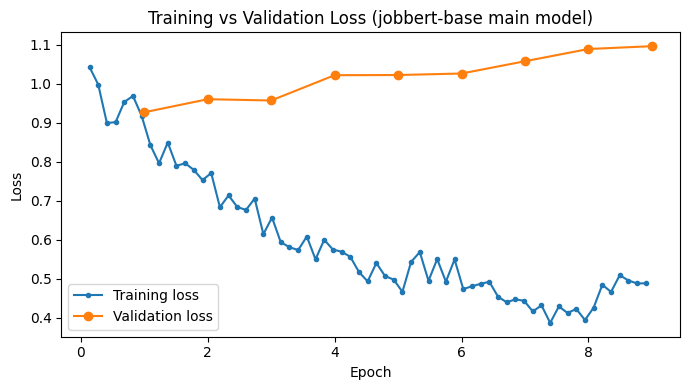

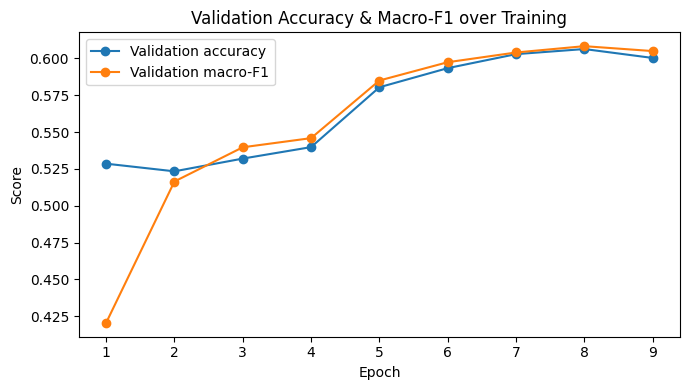

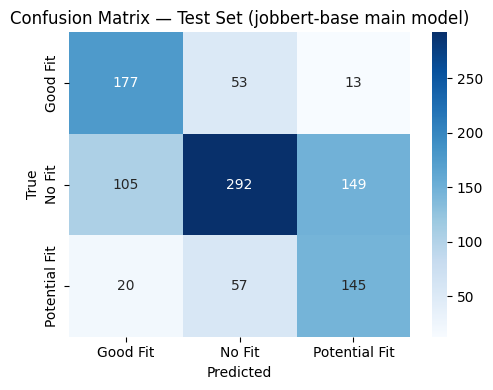


All 3 graphs saved to: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/


In [ ]:
# Cell 18: Generate training curves and confusion matrix plots
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)
eval_logs = log_df[log_df['eval_macro_f1'].notna()][['epoch', 'eval_loss', 'eval_accuracy', 'eval_macro_f1']]
train_logs = log_df[log_df['loss'].notna()][['epoch', 'loss']]

print(eval_logs)

# --- Plot 1: Loss curves ---
plt.figure(figsize=(7, 4))
plt.plot(train_logs['epoch'], train_logs['loss'], label='Training loss', marker='o', markersize=3)
plt.plot(eval_logs['epoch'], eval_logs['eval_loss'], label='Validation loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (jobbert-base main model)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/checkpoints/loss_curve.png', dpi=150)
plt.show()

# --- Plot 2: Accuracy & Macro-F1 curves ---
plt.figure(figsize=(7, 4))
plt.plot(eval_logs['epoch'], eval_logs['eval_accuracy'], label='Validation accuracy', marker='o')
plt.plot(eval_logs['epoch'], eval_logs['eval_macro_f1'], label='Validation macro-F1', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Accuracy & Macro-F1 over Training')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/checkpoints/accuracy_f1_curve.png', dpi=150)
plt.show()

# --- Plot 3: Confusion matrix heatmap (test set) ---
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Test Set (jobbert-base main model)')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/checkpoints/confusion_matrix.png', dpi=150)
plt.show()

print("\nAll 3 graphs saved to:", f'{PROJECT_DIR}/checkpoints/')

In [ ]:
# Cell 19: Reusable inference function for a single resume-JD pair
import torch.nn.functional as F

def predict_fit(resume_text, job_description_text):
    inputs = tokenizer(
        resume_text, job_description_text,
        truncation=True, max_length=512, padding=True, return_tensors="pt"
    ).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=-1)[0]

    pred_id = int(probs.argmax())
    result = {
        "predicted_label": model.config.id2label[pred_id],
        "confidence": round(float(probs[pred_id]) * 100, 1),
        "all_scores": {model.config.id2label[i]: round(float(probs[i]) * 100, 1) for i in range(len(probs))},
    }
    return result

# --- Quick sanity test ---
sample_resume = "Software Engineer with 5 years experience in Python, Django, REST APIs, and AWS."
sample_jd = "Looking for a Backend Developer skilled in Python, Django, and cloud deployment on AWS."

result = predict_fit(sample_resume, sample_jd)
print(result)

{'predicted_label': 'Good Fit', 'confidence': 59.5, 'all_scores': {'Good Fit': 59.5, 'No Fit': 21.8, 'Potential Fit': 18.7}}


In [ ]:
# Cell 20: Install parsing libraries and build a universal resume text extractor
!pip install -q pdfplumber python-docx

import pdfplumber
import docx
import re

def extract_text_from_file(filepath):
    """Extract raw text from a resume file (.pdf, .docx, or .txt)."""
    ext = filepath.lower().rsplit(".", 1)[-1]

    if ext == "pdf":
        text_parts = []
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text_parts.append(page_text)
        raw_text = "\n".join(text_parts)

    elif ext == "docx":
        d = docx.Document(filepath)
        raw_text = "\n".join(p.text for p in d.paragraphs)

    elif ext == "txt":
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            raw_text = f.read()

    else:
        raise ValueError(f"Unsupported file type: .{ext} (only pdf, docx, txt supported)")

    if not raw_text.strip():
        raise ValueError("No extractable text found — this may be a scanned/image-based file.")

    cleaned = re.sub(r'\n{3,}', '\n\n', raw_text)
    cleaned = re.sub(r'[ \t]{2,}', ' ', cleaned)
    return cleaned.strip()

print("Parser function ready. Supports: .pdf, .docx, .txt")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 81.7 MB/s eta 0:00:00
Parser function ready. Supports: .pdf, .docx, .txt


In [ ]:
# Cell 21: Upload a sample resume file and run it through the full pipeline
from google.colab import files

print("Choose a sample resume file (.pdf, .docx, or .txt):")
uploaded = files.upload()

test_filename = list(uploaded.keys())[0]
print(f"\nUploaded: {test_filename}")

extracted_text = extract_text_from_file(test_filename)
print(f"\nExtracted {len(extracted_text)} characters. Preview:\n")
print(extracted_text[:500])

# Test with a sample job description
sample_jd = "Looking for a Backend Developer skilled in Python, Django, and cloud deployment on AWS."

result = predict_fit(extracted_text, sample_jd)
print("\n--- Prediction ---")
print(result)

Choose a sample resume file (.pdf, .docx, or .txt):


Saving sample_resume.pdf to sample_resume.pdf

Uploaded: sample_resume.pdf

Extracted 1306 characters. Preview:

Tanvir Ahmed
Dhaka, Bangladesh | tanvir.ahmed@email.com | +880-1XXX-XXXXXX | linkedin.com/in/tanvirahmed
Summary
Backend-focused Software Engineer with 3 years of professional experience building REST APIs and
data pipelines in Python. Comfortable across the full backend stack: Django, PostgreSQL, Docker, and
AWS deployment.
Skills
Python, Django, Flask, REST API design, PostgreSQL, MySQL, Docker, AWS (EC2, S3, RDS), Git,
CI/CD, Unit Testing, Agile/Scrum
Experience
Backend Developer — NovaSoft L

--- Prediction ---
{'predicted_label': 'Good Fit', 'confidence': 73.4, 'all_scores': {'Good Fit': 73.4, 'No Fit': 13.8, 'Potential Fit': 12.7}}


In [ ]:
# Cell 22: Skill matching/gap analysis using the official ESCO taxonomy (13,897 skills)
!pip install -q spacy
!python -m spacy download en_core_web_sm -q

import pandas as pd
import spacy
from spacy.matcher import PhraseMatcher
import os

esco_path = f'{PROJECT_DIR}/data/esco_skills.csv'

if os.path.exists(esco_path):
    print("Found existing ESCO skills file — loading from Drive.")
    esco_df = pd.read_csv(esco_path)
else:
    esco_url = "https://raw.githubusercontent.com/tabiya-tech/tabiya-open-dataset/main/tabiya-esco-v1.1.1/csv/skills.csv"
    esco_df = pd.read_csv(esco_url)
    esco_df.to_csv(esco_path, index=False)
    print("Downloaded ESCO skills taxonomy and saved to Drive.")

print(f"Total ESCO skill concepts: {len(esco_df)}")
print("Columns:", esco_df.columns.tolist())

# Build a flat set of skill terms: preferred label + all alt labels
skill_terms = set()
for _, row in esco_df.iterrows():
    pref = str(row.get("PREFERREDLABEL", "")).strip()
    if pref and pref.lower() != "nan":
        skill_terms.add(pref.lower())
    alt = row.get("ALTLABELS", "")
    if isinstance(alt, str) and alt.strip():
        for label in alt.split("\n"):
            label = label.strip().lower()
            if label:
                skill_terms.add(label)

skill_terms = {t for t in skill_terms if len(t) > 2}  # drop overly short/noisy terms
print(f"Total unique skill terms (preferred + alt labels): {len(skill_terms)}")

nlp = spacy.load("en_core_web_sm")
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

skill_terms_list = list(skill_terms)
batch_size = 2000
for i in range(0, len(skill_terms_list), batch_size):
    batch = skill_terms_list[i:i + batch_size]
    patterns = [nlp.make_doc(t) for t in batch]
    matcher.add(f"SKILLS_{i}", patterns)

print("PhraseMatcher built with full ESCO taxonomy.")

def extract_skills(text):
    doc = nlp(text)
    matches = matcher(doc)
    return {doc[start:end].text.lower() for _, start, end in matches}

def get_skill_gap(resume_text, jd_text):
    resume_skills = extract_skills(resume_text)
    jd_skills = extract_skills(jd_text)
    return {
        "matched_skills": sorted(resume_skills & jd_skills),
        "missing_skills": sorted(jd_skills - resume_skills),
        "extra_skills": sorted(resume_skills - jd_skills),
    }

# --- Test with the same sample resume + JD ---
gap_result = get_skill_gap(extracted_text, sample_jd)
print("\nSkill gap analysis (ESCO-based):")
print(gap_result)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 101.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Downloaded ESCO skills taxonomy and saved to Drive.
Total ESCO skill concepts: 13896
Columns: ['ORIGINURI', 'ID', 'UUIDHISTORY', 'SKILLTYPE', 'REUSELEVEL', 'PREFERREDLABEL', 'ALTLABELS', 'DESCRIPTION', 'DEFINITION', 'SCOPENOTE']
Total unique skill terms (preferred + alt labels): 98388
PhraseMatcher built with full ESCO taxonomy.

Skill gap analysis (ESCO-based):
{'matched_skills': ['python'], 'missing_skills': ['cloud deployment'], 'extra_skills': ['agile', 'computer', 'computer science', 'data', 'design', 'engineering', 'git', 'mysql', 'postgresql', 'scrum']}


In [ ]:
# Cell 22.1: Supplement ESCO with specific tech tool/framework names ESCO often misses
TECH_SUPPLEMENT = [
    "django", "flask", "fastapi", "react", "angular", "vue", "next.js", "node.js", "express",
    "spring", "spring boot", ".net", "asp.net", "laravel", "ruby on rails",
    "aws", "amazon web services", "azure", "gcp", "google cloud platform",
    "docker", "kubernetes", "terraform", "jenkins", "github actions", "gitlab ci",
    "tensorflow", "pytorch", "keras", "scikit-learn", "pandas", "numpy",
    "mongodb", "redis", "elasticsearch", "graphql", "rest api", "grpc",
    "react native", "flutter", "swift", "kotlin",
]

# Add these into the same matcher (new batch, doesn't disturb existing patterns)
new_terms = [t for t in TECH_SUPPLEMENT if t not in skill_terms]
patterns = [nlp.make_doc(t) for t in new_terms]
matcher.add("TECH_SUPPLEMENT", patterns)
skill_terms.update(new_terms)

print(f"Added {len(new_terms)} tech-specific terms not covered by ESCO.")
print(f"Total skill vocabulary now: {len(skill_terms)}")

# --- Re-test with the same sample resume + JD ---
gap_result = get_skill_gap(extracted_text, sample_jd)
print("\nSkill gap analysis (ESCO + tech supplement):")
print(gap_result)

Added 36 tech-specific terms not covered by ESCO.
Total skill vocabulary now: 98424

Skill gap analysis (ESCO + tech supplement):
{'matched_skills': ['aws', 'django', 'python'], 'missing_skills': ['cloud deployment'], 'extra_skills': ['agile', 'computer', 'computer science', 'data', 'design', 'docker', 'engineering', 'flask', 'git', 'mysql', 'postgresql', 'rest api', 'scrum']}


In [ ]:
# Cell 22.2: Rebuild the matcher with stricter filtering (multi-word ESCO terms + curated tech list only)
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

filtered_skill_terms = set()
for _, row in esco_df.iterrows():
    pref = str(row.get("PREFERREDLABEL", "")).strip().lower()
    if pref and pref != "nan" and len(pref.split()) >= 2:   # require 2+ words
        filtered_skill_terms.add(pref)
    alt = row.get("ALTLABELS", "")
    if isinstance(alt, str) and alt.strip():
        for label in alt.split("\n"):
            label = label.strip().lower()
            if label and len(label.split()) >= 2:
                filtered_skill_terms.add(label)

# Add back the curated single-word tech terms (these are deliberately specific, not noisy)
filtered_skill_terms.update(TECH_SUPPLEMENT)

print(f"Skill vocabulary after noise filtering: {len(filtered_skill_terms)} "
      f"(was {len(skill_terms)})")

skill_terms = filtered_skill_terms
skill_terms_list = list(skill_terms)
batch_size = 2000
for i in range(0, len(skill_terms_list), batch_size):
    batch = skill_terms_list[i:i + batch_size]
    patterns = [nlp.make_doc(t) for t in batch]
    matcher.add(f"SKILLS_{i}", patterns)

print("Matcher rebuilt with filtered vocabulary.")

# --- Re-test ---
gap_result = get_skill_gap(extracted_text, sample_jd)
print("\nSkill gap analysis (filtered):")
print(gap_result)

Skill vocabulary after noise filtering: 96796 (was 98424)
Matcher rebuilt with filtered vocabulary.

Skill gap analysis (filtered):
{'matched_skills': ['aws', 'django'], 'missing_skills': ['cloud deployment'], 'extra_skills': ['computer science', 'docker', 'flask', 'rest api']}


In [ ]:
# Cell 22.3: Add core programming languages (single-word but specific, not noise)
PROGRAMMING_LANGUAGES = [
    "python", "java", "javascript", "typescript", "sql", "php", "c++", "c#",
    "ruby", "swift", "kotlin", "scala", "perl", "matlab", "bash", "html", "css",
    "golang", "rust",
]

TECH_SUPPLEMENT.extend(PROGRAMMING_LANGUAGES)
new_terms = [t for t in PROGRAMMING_LANGUAGES if t not in skill_terms]
patterns = [nlp.make_doc(t) for t in new_terms]
matcher.add("PROGRAMMING_LANGS", patterns)
skill_terms.update(new_terms)

print(f"Added {len(new_terms)} programming language terms.")
print(f"Total skill vocabulary now: {len(skill_terms)}")

# --- Re-test ---
gap_result = get_skill_gap(extracted_text, sample_jd)
print("\nSkill gap analysis (final):")
print(gap_result)

Added 17 programming language terms.
Total skill vocabulary now: 96813

Skill gap analysis (final):
{'matched_skills': ['aws', 'django', 'python'], 'missing_skills': ['cloud deployment'], 'extra_skills': ['computer science', 'docker', 'flask', 'rest api']}


In [ ]:
# Cell 23: Combine fit prediction + skill gap into one report function
def generate_report(candidate_name, target_role, resume_text, jd_text):
    fit_result = predict_fit(resume_text, jd_text)
    skill_result = get_skill_gap(resume_text, jd_text)

    return {
        "candidate_name": candidate_name,
        "target_role": target_role,
        "fit_score": fit_result,        # predicted_label, confidence, all_scores
        "skill_analysis": skill_result,  # matched_skills, missing_skills, extra_skills
        # "ai_recommendation": to be added later via Gemini API
    }

# --- Test end-to-end ---
report = generate_report(
    candidate_name="Tanvir Ahmed",
    target_role="Backend Developer",
    resume_text=extracted_text,
    jd_text=sample_jd,
)

import json
print(json.dumps(report, indent=2))

{
  "candidate_name": "Tanvir Ahmed",
  "target_role": "Backend Developer",
  "fit_score": {
    "predicted_label": "Good Fit",
    "confidence": 73.4,
    "all_scores": {
      "Good Fit": 73.4,
      "No Fit": 13.8,
      "Potential Fit": 12.7
    }
  },
  "skill_analysis": {
    "matched_skills": [
      "aws",
      "django",
      "python"
    ],
    "missing_skills": [
      "cloud deployment"
    ],
    "extra_skills": [
      "computer science",
      "docker",
      "flask",
      "rest api"
    ]
  }
}


In [ ]:
# Cell 25: Log in to Hugging Face (paste your write token when prompted)
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# Cell 26: Push the final model and tokenizer to Hugging Face Hub
repo_name = "careerlens-fit-classifier"  # feel free to rename

model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

from huggingface_hub import whoami
username = whoami()["name"]
print(f"\nPushed successfully!")
print(f"View your model at: https://huggingface.co/{username}/{repo_name}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ce4hwdj/model.safetensors:   0%|          |  572kB /  433MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]


Pushed successfully!
View your model at: https://huggingface.co/parvez30/careerlens-fit-classifier


In [ ]:
# Cell 24: Reload everything — model from Hugging Face Hub (avoids local path issues)
from google.colab import drive
drive.mount('/content/drive')

import os, json, torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch.nn.functional as F

PROJECT_DIR = '/content/drive/MyDrive/CareerLens_Capstone_C'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Load main model + tokenizer from Hugging Face Hub instead of local Drive path ---
HF_REPO = "parvez30/careerlens-fit-classifier"
model = AutoModelForSequenceClassification.from_pretrained(HF_REPO).to(device)
tokenizer = AutoTokenizer.from_pretrained(HF_REPO)
print("Model + tokenizer loaded from Hugging Face Hub:", HF_REPO)

# --- Reload label mapping (still from Drive, this is just a small JSON) ---
with open(f'{PROJECT_DIR}/data/label_mapping.json') as f:
    saved = json.load(f)
label2id = saved["label2id"]
id2label = {int(k): v for k, v in saved["id2label"].items()}
class_weights_saved = saved["class_weights"]

print("label2id:", label2id)

def predict_fit(resume_text, job_description_text):
    inputs = tokenizer(resume_text, job_description_text, truncation=True,
                        max_length=512, padding=True, return_tensors="pt").to(device)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(**inputs).logits, dim=-1)[0]
    pred_id = int(probs.argmax())
    return {
        "predicted_label": model.config.id2label[pred_id],
        "confidence": round(float(probs[pred_id]) * 100, 1),
        "all_scores": {model.config.id2label[i]: round(float(probs[i]) * 100, 1) for i in range(len(probs))},
    }

print("\nEverything reloaded. Ready to continue.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


config.json:   0%|          | 0.00/982 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.97k [00:00<?, ?B/s]

Model + tokenizer loaded from Hugging Face Hub: parvez30/careerlens-fit-classifier
label2id: {'Good Fit': 0, 'No Fit': 1, 'Potential Fit': 2}

Everything reloaded. Ready to continue.


In [ ]:
# Cell 28: Verify all comparison_results files are accessible from Drive
import os

COMPARISON_DIR = f'{PROJECT_DIR}/data/comparison_results'

if os.path.exists(COMPARISON_DIR):
    files = sorted(os.listdir(COMPARISON_DIR))
    print(f"Found {len(files)} files in comparison_results/:\n")
    for f in files:
        size_kb = os.path.getsize(f'{COMPARISON_DIR}/{f}') / 1024
        print(f"  {f}  ({size_kb:.1f} KB)")
else:
    print("comparison_results folder not found! Check the path or re-upload.")

Found 15 files in comparison_results/:

  bert_base_cased_classification_report.csv  (0.3 KB)
  bertbase_accuracy_f1_curve.png  (39.5 KB)
  bertbase_confusion_matrix.png  (26.1 KB)
  bertbase_loss_curve.png  (32.5 KB)
  bigru_accuracy_f1_curve.png  (43.2 KB)
  bigru_classification_report.csv  (0.3 KB)
  bigru_confusion_matrix.png  (25.6 KB)
  bigru_loss_curve.png  (32.2 KB)
  bilstm_accuracy_f1_curve.png  (43.3 KB)
  bilstm_classification_report.csv  (0.3 KB)
  bilstm_confusion_matrix.png  (23.8 KB)
  bilstm_loss_curve.png  (30.9 KB)
  final_4model_comparison_barchart.png  (41.1 KB)
  jobbert_base_classification_report.csv  (0.3 KB)
  model_comparison_results.csv  (0.3 KB)


In [ ]:
# Cell 29: Install the Gemini SDK and set up the client
!pip install -q google-genai

from google import genai
from getpass import getpass

GEMINI_API_KEY = getpass("Paste your Gemini API key: ")
client = genai.Client(api_key=GEMINI_API_KEY)

GEMINI_MODEL = "gemini-3.5-flash-lite"

# Quick sanity test
test_response = client.models.generate_content(
    model=GEMINI_MODEL,
    contents="Say hello in one short sentence.",
)
print("Test response:", test_response.text)

Paste your Gemini API key: ··········
Test response: Hello there, how can I help you today?


In [ ]:
# Cell 30.0: Re-download ESCO skills CSV (missing from Drive) + rebuild sample data/matcher
import pandas as pd
import spacy
from spacy.matcher import PhraseMatcher
import os

esco_path = f'{PROJECT_DIR}/data/esco_skills.csv'

esco_url = "https://raw.githubusercontent.com/tabiya-tech/tabiya-open-dataset/main/tabiya-esco-v1.1.1/csv/skills.csv"
esco_df = pd.read_csv(esco_url)
esco_df.to_csv(esco_path, index=False)
print(f"Re-downloaded ESCO skills ({len(esco_df)} rows) and saved to Drive:", esco_path)

# --- Sample resume text ---
extracted_text = """Tanvir Ahmed
Backend-focused Software Engineer with 3 years of professional experience building REST APIs
and data pipelines in Python. Comfortable across the full backend stack: Django, PostgreSQL,
Docker, and AWS deployment.
Skills: Python, Django, Flask, REST API design, PostgreSQL, MySQL, Docker, AWS (EC2, S3, RDS), Git, CI/CD
Experience: Backend Developer at NovaSoft Ltd, built and maintained REST APIs in Django,
migrated services to Docker containers on AWS EC2, optimized PostgreSQL queries."""

sample_jd = "Looking for a Backend Developer skilled in Python, Django, and cloud deployment on AWS."

# --- Rebuild the ESCO skill matcher ---
nlp = spacy.load("en_core_web_sm")
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

TECH_SUPPLEMENT = [
    "django", "flask", "fastapi", "react", "angular", "vue", "next.js", "node.js", "express",
    "spring", "spring boot", ".net", "asp.net", "laravel", "ruby on rails",
    "aws", "amazon web services", "azure", "gcp", "google cloud platform",
    "docker", "kubernetes", "terraform", "jenkins", "github actions", "gitlab ci",
    "tensorflow", "pytorch", "keras", "scikit-learn", "pandas", "numpy",
    "mongodb", "redis", "elasticsearch", "graphql", "rest api", "grpc",
    "react native", "flutter", "swift", "kotlin",
    "python", "java", "javascript", "typescript", "sql", "php", "c++", "c#",
    "ruby", "scala", "perl", "matlab", "bash", "html", "css", "golang", "rust",
]

skill_terms = set(TECH_SUPPLEMENT)
for _, row in esco_df.iterrows():
    pref = str(row.get("PREFERREDLABEL", "")).strip().lower()
    if pref and pref != "nan" and len(pref.split()) >= 2:
        skill_terms.add(pref)
    alt = row.get("ALTLABELS", "")
    if isinstance(alt, str) and alt.strip():
        for label in alt.split("\n"):
            label = label.strip().lower()
            if label and len(label.split()) >= 2:
                skill_terms.add(label)

skill_terms_list = list(skill_terms)
for i in range(0, len(skill_terms_list), 2000):
    batch = skill_terms_list[i:i + 2000]
    matcher.add(f"SKILLS_{i}", [nlp.make_doc(t) for t in batch])

def extract_skills(text):
    doc = nlp(text)
    return {doc[start:end].text.lower() for _, start, end in matcher(doc)}

def get_skill_gap(resume_text, jd_text):
    r, j = extract_skills(resume_text), extract_skills(jd_text)
    return {"matched_skills": sorted(r & j), "missing_skills": sorted(j - r), "extra_skills": sorted(r - j)}

print(f"Rebuilt: sample text, sample_jd, and skill matcher ({len(skill_terms)} terms)")

Re-downloaded ESCO skills (13896 rows) and saved to Drive: /content/drive/MyDrive/CareerLens_Capstone_C/data/esco_skills.csv
Rebuilt: sample text, sample_jd, and skill matcher (96813 terms)


In [ ]:
# Cell 30: Generate personalized AI recommendations using Gemini (realistic tone + formatted output)
import textwrap

def generate_recommendation(candidate_name, target_role, fit_result, skill_result):
    prompt = f"""You are a career coach helping a job seeker improve their application.

Candidate: {candidate_name}
Target role: {target_role}
Fit assessment: {fit_result['predicted_label']} ({fit_result['confidence']}% confidence)
Matched skills: {', '.join(skill_result['matched_skills']) or 'None found'}
Missing skills (required by the job but not found in the resume): {', '.join(skill_result['missing_skills']) or 'None'}

Write a short, encouraging, and realistic recommendation for this candidate, structured as
exactly 3 short paragraphs separated by a blank line (no headings, no markdown, no bullet
symbols — just plain paragraphs):

Paragraph 1: One honest strength based on the matched skills.
Paragraph 2: The most important 1-2 missing skills to address, and a concrete way to do it
(a course, a project, a certification).
Paragraph 3: One practical interview-prep tip specific to this role.

Keep the tone supportive but realistic — do not promise or guarantee job offers or outcomes.
Do not use markdown formatting, just plain text."""

    response = client.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt,
    )
    return response.text.strip()

def print_wrapped(text, width=100):
    for paragraph in text.split("\n\n"):
        print(textwrap.fill(paragraph.strip(), width=width))
        print()

# --- Test it ---
recommendation = generate_recommendation(
    candidate_name="Tanvir Ahmed",
    target_role="Backend Developer",
    fit_result=predict_fit(extracted_text, sample_jd),
    skill_result=get_skill_gap(extracted_text, sample_jd),
)
print_wrapped(recommendation)

Tanvir, your background in Python and Django combined with your AWS experience gives you a strong
foundation for this backend developer role. These matched skills show employers you already
understand core server-side logic and modern infrastructure tools, which positions you well as a
solid contender for the position.

To bridge the gap for this specific role, you need to clearly demonstrate hands-on cloud deployment
experience, which is currently missing from your resume. I recommend deploying one of your existing
Django projects to AWS using Elastic Beanstalk or ECS, and then adding this live project link and
architecture summary to your resume.

During your interviews, be prepared to walk through your deployment pipeline step by step,
explaining how you handled environment variables, database migrations, and scaling on AWS. Being
able to articulate your deployment troubleshooting process will reassure hiring managers that you
can manage production-ready applications independently.


In [ ]:
# Cell 31: Complete report generator (name+role -> fit score -> skill gap -> AI recommendation)
def generate_report(candidate_name, target_role, resume_text, jd_text):
    fit_result = predict_fit(resume_text, jd_text)
    skill_result = get_skill_gap(resume_text, jd_text)
    recommendation = generate_recommendation(candidate_name, target_role, fit_result, skill_result)

    return {
        "candidate_name": candidate_name,
        "target_role": target_role,
        "fit_score": fit_result,
        "skill_analysis": skill_result,
        "ai_recommendation": recommendation,
    }

# --- Test end-to-end ---
report = generate_report(
    candidate_name="Tanvir Ahmed",
    target_role="Backend Developer",
    resume_text=extracted_text,
    jd_text=sample_jd,
)

print("=" * 60)
print(f"Candidate: {report['candidate_name']}")
print(f"Target role: {report['target_role']}")
print("=" * 60)
print(f"\nFit: {report['fit_score']['predicted_label']} ({report['fit_score']['confidence']}% confidence)")
print(f"  All scores: {report['fit_score']['all_scores']}")
print(f"\nMatched skills: {', '.join(report['skill_analysis']['matched_skills'])}")
print(f"Missing skills: {', '.join(report['skill_analysis']['missing_skills'])}")
print(f"\nAI Recommendation:")
print_wrapped(report['ai_recommendation'])

Candidate: Tanvir Ahmed
Target role: Backend Developer

Fit: Good Fit (51.7% confidence)
  All scores: {'Good Fit': 51.7, 'No Fit': 17.3, 'Potential Fit': 31.0}

Matched skills: aws, django, python
Missing skills: cloud deployment

AI Recommendation:
Hi Tanvir, your strong foundation in Python and Django combined with your experience in AWS makes
you a genuinely promising match for this backend role, giving you a solid technical base to build
upon.

To close the gap on cloud deployment, which the employer is specifically looking for, consider
deploying a personal Django project using AWS services like Elastic Beanstalk or ECS, or pursue the
AWS Certified Developer Associate certification to prove your capabilities.

For your interviews, be ready to walk through how you would architect, scale, and securely deploy a
backend application from scratch on AWS, focusing on practical trade-offs around performance and
cost.



In [ ]:
# Cell 32: Upload the sample resume PDF again and re-run the full report
!pip install -q pdfplumber python-docx

import pdfplumber
import docx
import re
from google.colab import files

def extract_text_from_file(filepath):
    ext = filepath.lower().rsplit(".", 1)[-1]
    if ext == "pdf":
        text_parts = []
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text_parts.append(page_text)
        raw_text = "\n".join(text_parts)
    elif ext == "docx":
        d = docx.Document(filepath)
        raw_text = "\n".join(p.text for p in d.paragraphs)
    elif ext == "txt":
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            raw_text = f.read()
    else:
        raise ValueError(f"Unsupported file type: .{ext}")

    if not raw_text.strip():
        raise ValueError("No extractable text found.")

    cleaned = re.sub(r'\n{3,}', '\n\n', raw_text)
    cleaned = re.sub(r'[ \t]{2,}', ' ', cleaned)
    return cleaned.strip()

print("Choose sample_resume.pdf:")
uploaded = files.upload()
test_filename = list(uploaded.keys())[0]

extracted_text = extract_text_from_file(test_filename)
print(f"\nExtracted {len(extracted_text)} characters (should be ~1306, matching the original test)")

# --- Re-run the full report with the real, complete resume text ---
report = generate_report(
    candidate_name="Tanvir Ahmed",
    target_role="Backend Developer",
    resume_text=extracted_text,
    jd_text=sample_jd,
)

print("=" * 60)
print(f"Candidate: {report['candidate_name']}")
print(f"Target role: {report['target_role']}")
print("=" * 60)
print(f"\nFit: {report['fit_score']['predicted_label']} ({report['fit_score']['confidence']}% confidence)")
print(f"  All scores: {report['fit_score']['all_scores']}")
print(f"\nMatched skills: {', '.join(report['skill_analysis']['matched_skills'])}")
print(f"Missing skills: {', '.join(report['skill_analysis']['missing_skills'])}")
print(f"\nAI Recommendation:")
print_wrapped(report['ai_recommendation'])

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 691.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 24.6 MB/s eta 0:00:00
Choose sample_resume.pdf:


Saving sample_resume.pdf to sample_resume.pdf

Extracted 1306 characters (should be ~1306, matching the original test)
Candidate: Tanvir Ahmed
Target role: Backend Developer

Fit: Good Fit (73.4% confidence)
  All scores: {'Good Fit': 73.4, 'No Fit': 13.8, 'Potential Fit': 12.7}

Matched skills: aws, django, python
Missing skills: cloud deployment

AI Recommendation:
Hi Tanvir, you have a solid foundation as a Backend Developer with your demonstrated expertise in
Python and Django, which are complemented by your familiarity with AWS. This combination makes you a
strong candidate on paper and proves you have the core programming abilities needed to build robust
server-side applications.

The main gap to address for this specific role is cloud deployment, as the job requirements
explicitly look for hands-on deployment experience beyond basic AWS familiarity. You can bridge this
gap quickly by deploying a Django application to AWS using services like Elastic Beanstalk or ECS,
and then doc

In [ ]:
# Cell 34: Full interactive pipeline (using a widget for reliable multi-line paste)
from google.colab import files
import ipywidgets as widgets
from IPython.display import display

# --- Step 1: Upload the resume ---
print("Step 1 of 2: Choose your resume file (.pdf, .docx, or .txt)\n")
uploaded = files.upload()
resume_filename = list(uploaded.keys())[0]

resume_text_input = extract_text_from_file(resume_filename)
print(f"\nExtracted {len(resume_text_input)} characters. Preview:")
print(resume_text_input[:300])

first_line = next((line.strip() for line in resume_text_input.split("\n") if line.strip()), "Candidate")
candidate_name_input = first_line[:60]
print(f"\nDetected candidate name: {candidate_name_input}")

# --- Step 2: Role + JD via widgets (paste-safe) ---
role_box = widgets.Text(description="Role:", placeholder="e.g. Machine Learning Engineer", layout=widgets.Layout(width="500px"))
jd_box = widgets.Textarea(description="JD:", placeholder="Paste the full job description here", layout=widgets.Layout(width="700px", height="250px"))
submit_btn = widgets.Button(description="Generate Report", button_style="success")
output_area = widgets.Output()

def on_submit(b):
    with output_area:
        output_area.clear_output()
        target_role_input = role_box.value.strip()
        jd_text_input = jd_box.value.strip()
        print(f"Role: {target_role_input}")
        print(f"JD length: {len(jd_text_input)} characters")
        print("\nGenerating report...\n" + "=" * 60)

        report = generate_report(
            candidate_name=candidate_name_input,
            target_role=target_role_input,
            resume_text=resume_text_input,
            jd_text=jd_text_input,
        )

        print(f"\nCandidate: {report['candidate_name']}")
        print(f"Target role: {report['target_role']}")
        print("=" * 60)
        print(f"\nFit: {report['fit_score']['predicted_label']} ({report['fit_score']['confidence']}% confidence)")
        print(f"  All scores: {report['fit_score']['all_scores']}")
        print(f"\nMatched skills: {', '.join(report['skill_analysis']['matched_skills'])}")
        print(f"Missing skills: {', '.join(report['skill_analysis']['missing_skills'])}")
        print(f"\nAI Recommendation:")
        print_wrapped(report['ai_recommendation'])

submit_btn.on_click(on_submit)
print("\nStep 2 of 2: Fill in the role and paste the JD below, then click the button.\n")
display(role_box, jd_box, submit_btn, output_area)

Step 1 of 2: Choose your resume file (.pdf, .docx, or .txt)



Saving Md.Rahat Pervez.pdf to Md.Rahat Pervez (2).pdf

Extracted 3505 characters. Preview:
Md. Rahat Pervez
rahatpervez
Machine Learning Engineer rahatpervez.com
(+880) 1747525412 (whatsApp) rahatparvez.official@gmail.com rahatpervez
Career Summary Computer Science undergraduate (BSc, ULAB — final semester) with a strong focus on AI/ML over the
past year, building and comparing deep learn

Detected candidate name: Md. Rahat Pervez

Step 2 of 2: Fill in the role and paste the JD below, then click the button.



Text(value='', description='Role:', layout=Layout(width='500px'), placeholder='e.g. Machine Learning Engineer'…

Textarea(value='', description='JD:', layout=Layout(height='250px', width='700px'), placeholder='Paste the ful…

Button(button_style='success', description='Generate Report', style=ButtonStyle())

Output()

In [ ]:
# Cell 35: Demo — multi-turn Gemini chat, seeded with the candidate's report context
def start_career_chat(report):
    """Creates a Gemini chat session pre-loaded with the candidate's analysis context."""
    chat = client.chats.create(model=GEMINI_MODEL)

    context_message = f"""You are a career coach chatbot helping a job seeker. Here is their analysis:

Candidate: {report['candidate_name']}
Target role: {report['target_role']}
Fit assessment: {report['fit_score']['predicted_label']} ({report['fit_score']['confidence']}% confidence)
Matched skills: {', '.join(report['skill_analysis']['matched_skills']) or 'None'}
Missing skills: {', '.join(report['skill_analysis']['missing_skills']) or 'None'}
Your earlier recommendation was: {report['ai_recommendation']}

The candidate may now ask follow-up questions. Answer helpfully, briefly (2-4 sentences unless
asked for more detail), and stay grounded in the context above. Just acknowledge you're ready —
don't repeat the analysis back yet."""

    intro_response = chat.send_message(context_message)
    print("[System context loaded]\n")
    print("Assistant:", intro_response.text)
    return chat

# --- Start a chat session using the report from Cell 32/34 (Tanvir Ahmed's report) ---
career_chat = start_career_chat(report)

print("\n" + "=" * 60)
print("Now let's ask follow-up questions (multi-turn demo):")
print("=" * 60)

q1 = "Which of the two options you suggested — the AWS course or the deployment project — should I prioritize if I only have 2 weeks?"
r1 = career_chat.send_message(q1)
print(f"\nUser: {q1}")
print(f"Assistant: {r1.text}")

q2 = "Okay, I'll do the deployment project. What's the very first step I should take tomorrow?"
r2 = career_chat.send_message(q2)
print(f"\nUser: {q2}")
print(f"Assistant: {r2.text}")

[System context loaded]

Assistant: I'm ready! What questions do you have about your job search or preparing for your Machine Learning Engineer interviews?

Now let's ask follow-up questions (multi-turn demo):

User: Which of the two options you suggested — the AWS course or the deployment project — should I prioritize if I only have 2 weeks?
Assistant: With only two weeks, definitely prioritize the **hands-on end-to-end deployment project**. Building a quick project on AWS or GCP allows you to tangibly showcase your MLOps and cloud skills on your resume, which hiring managers value more than a course certificate. You can always use quick-start tutorials (like SageMaker or Vertex AI) to get it up and running fast within your timeframe.

User: Okay, I'll do the deployment project. What's the very first step I should take tomorrow?
Assistant: Your very first step tomorrow is to choose a simple, pre-trained model or a dataset you've already worked with so you don't waste time on model tra

In [ ]:
# Cell 36: Rule-based job category classifier (for fairness/bias evaluation)
import pandas as pd

test_clean = pd.read_csv(f'{PROJECT_DIR}/data/test_clean.csv')
print(f"Test set: {len(test_clean)} rows")

CATEGORY_KEYWORDS = {
    "IT/Software": ["software", "developer", "programmer", "engineer", " it ", "data scientist",
                     "data analyst", "devops", "qa ", "network", "system administrator", "cybersecurity"],
    "Healthcare": ["nurse", "medical", "clinical", "patient", "healthcare", "physician", "pharmacy", "dental"],
    "Sales": ["sales", "account executive", "business development", "retail associate"],
    "Finance/Accounting": ["accounting", "accountant", "finance", "financial", "audit", "bookkeeping", "tax"],
    "Marketing": ["marketing", "seo", "content", "social media", "brand", "advertising"],
    "HR": ["human resources", "recruiter", "talent acquisition", " hr "],
    "Engineering (non-software)": ["mechanical", "electrical", "civil engineer", "manufacturing", "industrial engineer"],
    "Education": ["teacher", "instructor", "professor", "curriculum", "tutor"],
    "Customer Service": ["customer service", "support representative", "call center"],
    "Construction": ["construction", "electrician", "plumb", "foreman"],
}

def categorize_jd(jd_text):
    jd_lower = f" {str(jd_text).lower()} "
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in jd_lower for kw in keywords):
            return category
    return "Other"

test_clean["job_category"] = test_clean["job_description_text"].apply(categorize_jd)
print("\nCategory distribution in test set:")
print(test_clean["job_category"].value_counts())

Test set: 1011 rows

Category distribution in test set:
job_category
IT/Software           837
Finance/Accounting     90
Healthcare             37
Other                  20
Sales                  20
Marketing               7
Name: count, dtype: int64


In [ ]:
# Cell 38.4: Swap the job posting to Civil Engineer — does the ranking flip appropriately?
civil_job_posting = """We are seeking a licensed Civil Engineer to supervise construction of residential
and commercial buildings. Must have experience with structural analysis, AutoCAD, and site supervision."""

results_civil = []
for filename in uploaded.keys():  # reusing the same 5 uploaded files from Cell 38.3
    resume_text = extract_text_from_file(filename)
    fit = predict_fit(resume_text, civil_job_posting)
    results_civil.append({
        "file": filename,
        "predicted_label": fit["predicted_label"],
        "confidence": fit["confidence"],
        "all_scores": fit["all_scores"],
    })

results_civil_sorted = sorted(results_civil, key=lambda x: x["all_scores"]["Good Fit"], reverse=True)

print("=" * 80)
print("RESULTS for CIVIL ENGINEER job posting — ranked by Good Fit score")
print("(If the model is JD-sensitive, Rafiqul/demo_cv_5 should now rank #1)")
print("=" * 80)
for i, r in enumerate(results_civil_sorted, 1):
    print(f"\n{i}. {r['file']}")
    print(f"   Prediction: {r['predicted_label']}  ({r['confidence']}% confidence)")
    print(f"   All scores: {r['all_scores']}")

RESULTS for CIVIL ENGINEER job posting — ranked by Good Fit score
(If the model is JD-sensitive, Rafiqul/demo_cv_5 should now rank #1)

1. demo_cv_2_marketing_weak.pdf
   Prediction: Good Fit  (78.3% confidence)
   All scores: {'Good Fit': 78.3, 'No Fit': 11.2, 'Potential Fit': 10.5}

2. demo_cv_4_data_scientist.pdf
   Prediction: Good Fit  (77.7% confidence)
   All scores: {'Good Fit': 77.7, 'No Fit': 11.0, 'Potential Fit': 11.4}

3. demo_cv_1_backend_strong.pdf
   Prediction: Good Fit  (73.4% confidence)
   All scores: {'Good Fit': 73.4, 'No Fit': 14.0, 'Potential Fit': 12.6}

4. demo_cv_3_frontend_partial.pdf
   Prediction: Good Fit  (61.9% confidence)
   All scores: {'Good Fit': 61.9, 'No Fit': 16.5, 'Potential Fit': 21.5}

5. demo_cv_5_civil_engineer.pdf
   Prediction: Good Fit  (61.4% confidence)
   All scores: {'Good Fit': 61.4, 'No Fit': 15.4, 'Potential Fit': 23.2}


In [ ]:
# Cell A: Reload model + tokenizer (from Drive mount + HF Hub)
from google.colab import drive
drive.mount('/content/drive')

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch.nn.functional as F

PROJECT_DIR = '/content/drive/MyDrive/CareerLens_Capstone_C'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

HF_REPO = "parvez30/careerlens-fit-classifier"
model = AutoModelForSequenceClassification.from_pretrained(HF_REPO).to(device)
tokenizer = AutoTokenizer.from_pretrained(HF_REPO)
print("Model + tokenizer loaded from:", HF_REPO)

def predict_fit(resume_text, job_description_text):
    inputs = tokenizer(resume_text, job_description_text, truncation=True,
                        max_length=512, padding=True, return_tensors="pt").to(device)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(**inputs).logits, dim=-1)[0]
    pred_id = int(probs.argmax())
    return {
        "predicted_label": model.config.id2label[pred_id],
        "confidence": round(float(probs[pred_id]) * 100, 1),
        "all_scores": {model.config.id2label[i]: round(float(probs[i]) * 100, 1) for i in range(len(probs))},
    }

print("predict_fit() ready.")

Mounted at /content/drive
Device: cpu


config.json:   0%|          | 0.00/982 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.97k [00:00<?, ?B/s]

Model + tokenizer loaded from: parvez30/careerlens-fit-classifier
predict_fit() ready.


In [ ]:
# Cell B: Re-define extract_text_from_file
!pip install -q pdfplumber python-docx

import pdfplumber
import docx
import re

def extract_text_from_file(filepath):
    ext = filepath.lower().rsplit(".", 1)[-1]
    if ext == "pdf":
        text_parts = []
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text_parts.append(page_text)
        raw_text = "\n".join(text_parts)
    elif ext == "docx":
        d = docx.Document(filepath)
        raw_text = "\n".join(p.text for p in d.paragraphs)
    elif ext == "txt":
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            raw_text = f.read()
    else:
        raise ValueError(f"Unsupported file type: .{ext}")
    if not raw_text.strip():
        raise ValueError("No extractable text found.")
    cleaned = re.sub(r'\n{3,}', '\n\n', raw_text)
    cleaned = re.sub(r'[ \t]{2,}', ' ', cleaned)
    return cleaned.strip()

print("extract_text_from_file() ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 14.2 MB/s eta 0:00:00
extract_text_from_file() ready.


In [ ]:
# Cell C: Upload the 5 demo CVs again
from google.colab import files

print("Select all 5 demo CVs at once (Ctrl/Cmd+click to multi-select):\n")
uploaded = files.upload()
print("\nUploaded:", list(uploaded.keys()))

Select all 5 demo CVs at once (Ctrl/Cmd+click to multi-select):



Saving demo_cv_1_backend_strong.pdf to demo_cv_1_backend_strong.pdf
Saving demo_cv_2_marketing_weak.pdf to demo_cv_2_marketing_weak.pdf
Saving demo_cv_3_frontend_partial.pdf to demo_cv_3_frontend_partial.pdf
Saving demo_cv_4_data_scientist.pdf to demo_cv_4_data_scientist.pdf
Saving demo_cv_5_civil_engineer.pdf to demo_cv_5_civil_engineer.pdf

Uploaded: ['demo_cv_1_backend_strong.pdf', 'demo_cv_2_marketing_weak.pdf', 'demo_cv_3_frontend_partial.pdf', 'demo_cv_4_data_scientist.pdf', 'demo_cv_5_civil_engineer.pdf']


In [ ]:
# Cell 40: Test ranking sensitivity across 3 different IT job postings (fair, in-domain test)
backend_jd = """We are seeking a Backend Developer skilled in Python, Django, and cloud deployment on AWS.
Must have experience with REST API design and PostgreSQL."""

data_scientist_jd = """We are seeking a Data Scientist experienced in building machine learning models
using Python, Pandas, and Scikit-learn. Experience with SQL and deploying models on AWS SageMaker is required."""

frontend_jd = """We are seeking a Frontend Developer experienced in building responsive web interfaces
using JavaScript, React, and modern CSS. Experience with Redux and Webpack is a plus."""

it_candidates = {
    "Tanvir (Backend)": "demo_cv_1_backend_strong.pdf",
    "Priya (Data Scientist)": "demo_cv_4_data_scientist.pdf",
    "James (Frontend)": "demo_cv_3_frontend_partial.pdf",
    "Sarah (Marketing, control)": "demo_cv_2_marketing_weak.pdf",
}

for jd_name, jd_text in [("Backend Developer JD", backend_jd),
                          ("Data Scientist JD", data_scientist_jd),
                          ("Frontend Developer JD", frontend_jd)]:
    print("=" * 70)
    print(f"JOB POSTING: {jd_name}")
    print("=" * 70)
    scores = []
    for cand_name, filename in it_candidates.items():
        resume_text = extract_text_from_file(filename)
        fit = predict_fit(resume_text, jd_text)
        scores.append((cand_name, fit["all_scores"]["Good Fit"]))
    scores.sort(key=lambda x: x[1], reverse=True)
    for i, (name, score) in enumerate(scores, 1):
        print(f"  {i}. {name}: {score}% Good Fit")
    print()

JOB POSTING: Backend Developer JD
  1. Sarah (Marketing, control): 78.5% Good Fit
  2. Priya (Data Scientist): 77.8% Good Fit
  3. Tanvir (Backend): 73.1% Good Fit
  4. James (Frontend): 61.7% Good Fit

JOB POSTING: Data Scientist JD
  1. Priya (Data Scientist): 78.5% Good Fit
  2. Sarah (Marketing, control): 77.6% Good Fit
  3. Tanvir (Backend): 74.4% Good Fit
  4. James (Frontend): 64.0% Good Fit

JOB POSTING: Frontend Developer JD
  1. Sarah (Marketing, control): 78.2% Good Fit
  2. Priya (Data Scientist): 78.1% Good Fit
  3. Tanvir (Backend): 73.6% Good Fit
  4. James (Frontend): 62.3% Good Fit



In [ ]:
# Cell D: Rebuild the skill matcher from the cached ESCO CSV in Drive
import pandas as pd
import spacy
from spacy.matcher import PhraseMatcher

esco_df = pd.read_csv(f'{PROJECT_DIR}/data/esco_skills.csv')
print(f"Loaded ESCO CSV: {len(esco_df)} rows")

nlp = spacy.load("en_core_web_sm")
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

TECH_SUPPLEMENT = [
    "django", "flask", "fastapi", "react", "angular", "vue", "next.js", "node.js", "express",
    "spring", "spring boot", ".net", "asp.net", "laravel", "ruby on rails",
    "aws", "amazon web services", "azure", "gcp", "google cloud platform",
    "docker", "kubernetes", "terraform", "jenkins", "github actions", "gitlab ci",
    "tensorflow", "pytorch", "keras", "scikit-learn", "pandas", "numpy",
    "mongodb", "redis", "elasticsearch", "graphql", "rest api", "grpc",
    "react native", "flutter", "swift", "kotlin",
    "python", "java", "javascript", "typescript", "sql", "php", "c++", "c#",
    "ruby", "scala", "perl", "matlab", "bash", "html", "css", "golang", "rust",
    "redux", "webpack", "sagemaker",
]

skill_terms = set(TECH_SUPPLEMENT)
for _, row in esco_df.iterrows():
    pref = str(row.get("PREFERREDLABEL", "")).strip().lower()
    if pref and pref != "nan" and len(pref.split()) >= 2:
        skill_terms.add(pref)
    alt = row.get("ALTLABELS", "")
    if isinstance(alt, str) and alt.strip():
        for label in alt.split("\n"):
            label = label.strip().lower()
            if label and len(label.split()) >= 2:
                skill_terms.add(label)

skill_terms_list = list(skill_terms)
for i in range(0, len(skill_terms_list), 2000):
    batch = skill_terms_list[i:i + 2000]
    matcher.add(f"SKILLS_{i}", [nlp.make_doc(t) for t in batch])

def extract_skills(text):
    doc = nlp(text)
    return {doc[start:end].text.lower() for _, start, end in matcher(doc)}

def get_skill_gap(resume_text, jd_text):
    r, j = extract_skills(resume_text), extract_skills(jd_text)
    return {"matched_skills": sorted(r & j), "missing_skills": sorted(j - r), "extra_skills": sorted(r - j)}

print(f"Skill matcher ready: {len(skill_terms)} terms")

Loaded ESCO CSV: 13896 rows
Skill matcher ready: 96816 terms


In [ ]:
# Cell 41 (updated): Hybrid safety net with a 3-tier downgrade (No Fit / Potential Fit / unchanged)
def predict_fit_safe(resume_text, jd_text):
    model_result = predict_fit(resume_text, jd_text)
    skill_result = get_skill_gap(resume_text, jd_text)
    matched_count = len(skill_result["matched_skills"])
    missing_count = len(skill_result["missing_skills"])
    total_required = matched_count + missing_count
    overlap_ratio = matched_count / total_required if total_required > 0 else None

    final_label = model_result["predicted_label"]
    warning = None

    if overlap_ratio is not None and final_label == "Good Fit":
        if overlap_ratio == 0:
            final_label = "No Fit"
            warning = "Downgraded to No Fit: zero required skills matched"
        elif overlap_ratio < 0.3:
            final_label = "Potential Fit"
            warning = f"Downgraded to Potential Fit: {matched_count}/{total_required} skills matched ({overlap_ratio:.0%})"
    elif total_required == 0:
        warning = "No skills detected in JD — model-only result, verify manually"

    return {
        "final_label": final_label,
        "model_said": model_result["predicted_label"],
        "good_fit_score": model_result["all_scores"]["Good Fit"],
        "overlap": overlap_ratio,
        "matched": skill_result["matched_skills"],
        "warning": warning,
    }

# --- Re-run the same IT-domain test with the refined logic ---
for jd_name, jd_text in [("Backend Developer JD", backend_jd), ("Data Scientist JD", data_scientist_jd), ("Frontend Developer JD", frontend_jd)]:
    print("=" * 70); print(f"JOB POSTING: {jd_name}"); print("=" * 70)
    for cand_name, filename in it_candidates.items():
        resume_text = extract_text_from_file(filename)
        r = predict_fit_safe(resume_text, jd_text)
        flag = f"  ⚠ {r['warning']}" if r['warning'] else ""
        print(f"  {cand_name}: model={r['model_said']} ({r['good_fit_score']}%) -> FINAL={r['final_label']}  overlap={r['overlap']}  matched={r['matched']}{flag}")
    print()

JOB POSTING: Backend Developer JD
  Tanvir (Backend): model=Good Fit (73.1%) -> FINAL=Good Fit  overlap=0.8  matched=['aws', 'django', 'python', 'rest api']
  Priya (Data Scientist): model=Good Fit (77.8%) -> FINAL=Good Fit  overlap=0.4  matched=['aws', 'python']
  James (Frontend): model=Good Fit (61.7%) -> FINAL=Potential Fit  overlap=0.2  matched=['python']  ⚠ Downgraded to Potential Fit: 1/5 skills matched (20%)
  Sarah (Marketing, control): model=Good Fit (78.5%) -> FINAL=No Fit  overlap=0.0  matched=[]  ⚠ Downgraded to No Fit: zero required skills matched

JOB POSTING: Data Scientist JD
  Tanvir (Backend): model=Good Fit (74.4%) -> FINAL=Potential Fit  overlap=0.2857142857142857  matched=['aws', 'python']  ⚠ Downgraded to Potential Fit: 2/7 skills matched (29%)
  Priya (Data Scientist): model=Good Fit (78.5%) -> FINAL=Good Fit  overlap=1.0  matched=['aws', 'machine learning', 'pandas', 'python', 'sagemaker', 'scikit-learn', 'sql']
  James (Frontend): model=Good Fit (64.0%) -> FIN

In [ ]:
# Cell 42 (fixed): Recruiter-side ranking — sort by skill overlap within each Fit tier
import pandas as pd

all_candidates = {
    "Tanvir Ahmed (Backend)": "demo_cv_1_backend_strong.pdf",
    "Sarah Khan (Marketing)": "demo_cv_2_marketing_weak.pdf",
    "James Lee (Frontend)": "demo_cv_3_frontend_partial.pdf",
    "Priya Sharma (Data Scientist)": "demo_cv_4_data_scientist.pdf",
    "Rafiqul Islam (Civil Engineer)": "demo_cv_5_civil_engineer.pdf",
}

LABEL_PRIORITY = {"Good Fit": 0, "Potential Fit": 1, "No Fit": 2}

def rank_for_job(job_title, jd_text, candidates_dict):
    rows = []
    for name, filename in candidates_dict.items():
        resume_text = extract_text_from_file(filename)
        r = predict_fit_safe(resume_text, jd_text)
        overlap_val = r["overlap"] if r["overlap"] is not None else -1  # unknown overlap sorts last
        rows.append({
            "Candidate": name,
            "Fit": r["final_label"],
            "Model Confidence": r["good_fit_score"],
            "Skill Match": overlap_val,
            "Matched Skills": ", ".join(r["matched"]) if r["matched"] else "—",
        })
    df = pd.DataFrame(rows)
    df["_sort_key"] = df["Fit"].map(LABEL_PRIORITY)
    # Sort by: Fit tier first, then Skill Match (more trustworthy than raw confidence), then confidence
    df = df.sort_values(by=["_sort_key", "Skill Match", "Model Confidence"], ascending=[True, False, False])
    df = df.drop(columns="_sort_key").reset_index(drop=True)
    df.insert(0, "Rank", range(1, len(df) + 1))

    # Format for display after sorting
    df["Model Confidence"] = df["Model Confidence"].map(lambda x: f"{x}%")
    df["Skill Match"] = df["Skill Match"].map(lambda x: f"{x*100:.0f}%" if x >= 0 else "N/A")

    print(f"\n{'='*90}\nRecruiter view — Job Posting: {job_title}\n{'='*90}")
    display(df)
    return df

_ = rank_for_job("Backend Developer", backend_jd, all_candidates)
_ = rank_for_job("Data Scientist", data_scientist_jd, all_candidates)
_ = rank_for_job("Frontend Developer", frontend_jd, all_candidates)


Recruiter view — Job Posting: Backend Developer


,Rank,Candidate,Fit,Model Confidence,Skill Match,Matched Skills
0,1,Tanvir Ahmed (Backend),Good Fit,73.1%,80%,"aws, django, python, rest api"
1,2,Priya Sharma (Data Scientist),Good Fit,77.8%,40%,"aws, python"
2,3,James Lee (Frontend),Potential Fit,61.7%,20%,python
3,4,Sarah Khan (Marketing),No Fit,78.5%,0%,—
4,5,Rafiqul Islam (Civil Engineer),No Fit,61.3%,0%,—



Recruiter view — Job Posting: Data Scientist


,Rank,Candidate,Fit,Model Confidence,Skill Match,Matched Skills
0,1,Priya Sharma (Data Scientist),Good Fit,78.5%,100%,"aws, machine learning, pandas, python, sagemak..."
1,2,Tanvir Ahmed (Backend),Potential Fit,74.4%,29%,"aws, python"
2,3,James Lee (Frontend),Potential Fit,64.0%,29%,"python, sql"
3,4,Sarah Khan (Marketing),No Fit,77.6%,0%,—
4,5,Rafiqul Islam (Civil Engineer),No Fit,60.6%,0%,—



Recruiter view — Job Posting: Frontend Developer


,Rank,Candidate,Fit,Model Confidence,Skill Match,Matched Skills
0,1,James Lee (Frontend),Good Fit,62.3%,100%,"css, javascript, react, redux, webpack"
1,2,Sarah Khan (Marketing),No Fit,78.2%,0%,—
2,3,Priya Sharma (Data Scientist),No Fit,78.1%,0%,—
3,4,Tanvir Ahmed (Backend),No Fit,73.6%,0%,—
4,5,Rafiqul Islam (Civil Engineer),No Fit,61.4%,0%,—


In [ ]:
# Cell 43: Save the full CareerLens ML pipeline as a single, clean Python file to Drive
pipeline_code = '''"""
CareerLens - Core ML Pipeline
Main model: parvez30/careerlens-fit-classifier (jjzha/jobbert-base-cased, fine-tuned)
Skill matching: ESCO taxonomy (13,896 skills) + curated tech supplement
Recommendation/chat: Google Gemini API (gemini-3.5-flash-lite)

This file is the single source of truth for the fit-prediction pipeline.
Import these functions directly in the FastAPI backend.
"""

import re
import torch
import torch.nn.functional as F
import spacy
from spacy.matcher import PhraseMatcher
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from google import genai

HF_REPO = "parvez30/careerlens-fit-classifier"
GEMINI_MODEL = "gemini-3.5-flash-lite"

TECH_SUPPLEMENT = [
    "django", "flask", "fastapi", "react", "angular", "vue", "next.js", "node.js", "express",
    "spring", "spring boot", ".net", "asp.net", "laravel", "ruby on rails",
    "aws", "amazon web services", "azure", "gcp", "google cloud platform",
    "docker", "kubernetes", "terraform", "jenkins", "github actions", "gitlab ci",
    "tensorflow", "pytorch", "keras", "scikit-learn", "pandas", "numpy",
    "mongodb", "redis", "elasticsearch", "graphql", "rest api", "grpc",
    "react native", "flutter", "swift", "kotlin",
    "python", "java", "javascript", "typescript", "sql", "php", "c++", "c#",
    "ruby", "scala", "perl", "matlab", "bash", "html", "css", "golang", "rust",
    "redux", "webpack", "sagemaker",
]


def load_model(device=None):
    """Load the main fit-classification model and tokenizer from Hugging Face Hub."""
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModelForSequenceClassification.from_pretrained(HF_REPO).to(device)
    tokenizer = AutoTokenizer.from_pretrained(HF_REPO)
    return model, tokenizer, device


def build_skill_matcher(esco_csv_path):
    """Build the ESCO + tech-supplement PhraseMatcher for skill extraction."""
    import pandas as pd
    esco_df = pd.read_csv(esco_csv_path)
    nlp = spacy.load("en_core_web_sm")
    matcher = PhraseMatcher(nlp.vocab, attr="LOWER")

    skill_terms = set(TECH_SUPPLEMENT)
    for _, row in esco_df.iterrows():
        pref = str(row.get("PREFERREDLABEL", "")).strip().lower()
        if pref and pref != "nan" and len(pref.split()) >= 2:
            skill_terms.add(pref)
        alt = row.get("ALTLABELS", "")
        if isinstance(alt, str) and alt.strip():
            for label in alt.split("\\n"):
                label = label.strip().lower()
                if label and len(label.split()) >= 2:
                    skill_terms.add(label)

    skill_terms_list = list(skill_terms)
    for i in range(0, len(skill_terms_list), 2000):
        batch = skill_terms_list[i:i + 2000]
        matcher.add(f"SKILLS_{i}", [nlp.make_doc(t) for t in batch])

    return nlp, matcher


def extract_text_from_file(filepath):
    """Extract raw text from a resume file (.pdf, .docx, or .txt)."""
    import pdfplumber
    import docx

    ext = filepath.lower().rsplit(".", 1)[-1]
    if ext == "pdf":
        text_parts = []
        with pdfplumber.open(filepath) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text_parts.append(page_text)
        raw_text = "\\n".join(text_parts)
    elif ext == "docx":
        d = docx.Document(filepath)
        raw_text = "\\n".join(p.text for p in d.paragraphs)
    elif ext == "txt":
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            raw_text = f.read()
    else:
        raise ValueError(f"Unsupported file type: .{ext}")

    if not raw_text.strip():
        raise ValueError("No extractable text found — this may be a scanned/image-based file.")

    cleaned = re.sub(r"\\n{3,}", "\\n\\n", raw_text)
    cleaned = re.sub(r"[ \\t]{2,}", " ", cleaned)
    return cleaned.strip()


def predict_fit(resume_text, jd_text, model, tokenizer, device):
    """Raw model prediction (before the skill-overlap safety net)."""
    inputs = tokenizer(resume_text, jd_text, truncation=True, max_length=512,
                        padding=True, return_tensors="pt").to(device)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(**inputs).logits, dim=-1)[0]
    pred_id = int(probs.argmax())
    return {
        "predicted_label": model.config.id2label[pred_id],
        "confidence": round(float(probs[pred_id]) * 100, 1),
        "all_scores": {model.config.id2label[i]: round(float(probs[i]) * 100, 1) for i in range(len(probs))},
    }


def extract_skills(text, nlp, matcher):
    doc = nlp(text)
    return {doc[start:end].text.lower() for _, start, end in matcher(doc)}


def get_skill_gap(resume_text, jd_text, nlp, matcher):
    r = extract_skills(resume_text, nlp, matcher)
    j = extract_skills(jd_text, nlp, matcher)
    return {
        "matched_skills": sorted(r & j),
        "missing_skills": sorted(j - r),
        "extra_skills": sorted(r - j),
    }


def predict_fit_safe(resume_text, jd_text, model, tokenizer, device, nlp, matcher):
    """
    Main entry point for fit prediction. Combines the raw model prediction with an
    ESCO skill-overlap sanity check, since adversarial testing showed the raw model
    has weak JD-sensitivity (it can score an unrelated resume as "Good Fit").
    Downgrades: 0% overlap -> No Fit, <30% overlap -> Potential Fit.
    Use this function (not predict_fit alone) for both job-seeker fit scoring and
    recruiter-side candidate ranking.
    """
    model_result = predict_fit(resume_text, jd_text, model, tokenizer, device)
    skill_result = get_skill_gap(resume_text, jd_text, nlp, matcher)

    matched_count = len(skill_result["matched_skills"])
    missing_count = len(skill_result["missing_skills"])
    total_required = matched_count + missing_count
    overlap_ratio = matched_count / total_required if total_required > 0 else None

    final_label = model_result["predicted_label"]
    warning = None

    if overlap_ratio is not None and final_label == "Good Fit":
        if overlap_ratio == 0:
            final_label = "No Fit"
            warning = "Downgraded to No Fit: zero required skills matched"
        elif overlap_ratio < 0.3:
            final_label = "Potential Fit"
            warning = f"Downgraded to Potential Fit: {matched_count}/{total_required} skills matched ({overlap_ratio:.0%})"
    elif total_required == 0:
        warning = "No skills detected in JD — model-only result, verify manually"

    return {
        "final_label": final_label,
        "model_predicted_label": model_result["predicted_label"],
        "confidence": model_result["confidence"],
        "all_scores": model_result["all_scores"],
        "skill_overlap_ratio": overlap_ratio,
        "matched_skills": skill_result["matched_skills"],
        "missing_skills": skill_result["missing_skills"],
        "warning": warning,
    }


def generate_recommendation(candidate_name, target_role, fit_result, skill_result, gemini_client):
    """Generate a 3-paragraph AI recommendation using Gemini (strength / gap-action / interview tip)."""
    prompt = f"""You are a career coach helping a job seeker improve their application.

Candidate: {candidate_name}
Target role: {target_role}
Fit assessment: {fit_result['final_label']} ({fit_result['confidence']}% model confidence)
Matched skills: {', '.join(skill_result['matched_skills']) or 'None found'}
Missing skills: {', '.join(skill_result['missing_skills']) or 'None'}

Write a short, encouraging, and realistic recommendation for this candidate, structured as
exactly 3 short paragraphs separated by a blank line (no headings, no markdown, no bullet
symbols — just plain paragraphs):

Paragraph 1: One honest strength based on the matched skills.
Paragraph 2: The most important 1-2 missing skills to address, and a concrete way to do it.
Paragraph 3: One practical interview-prep tip specific to this role.

Keep the tone supportive but realistic — do not promise or guarantee job offers or outcomes.
Do not use markdown formatting, just plain text."""

    response = gemini_client.models.generate_content(model=GEMINI_MODEL, contents=prompt)
    return response.text.strip()


def generate_report(candidate_name, target_role, resume_text, jd_text,
                     model, tokenizer, device, nlp, matcher, gemini_client):
    """Full pipeline: fit score (with safety net) -> skill gap -> AI recommendation."""
    fit_result = predict_fit_safe(resume_text, jd_text, model, tokenizer, device, nlp, matcher)
    skill_result = {
        "matched_skills": fit_result["matched_skills"],
        "missing_skills": fit_result["missing_skills"],
    }
    recommendation = generate_recommendation(candidate_name, target_role, fit_result, skill_result, gemini_client)

    return {
        "candidate_name": candidate_name,
        "target_role": target_role,
        "fit_score": fit_result,
        "skill_analysis": skill_result,
        "ai_recommendation": recommendation,
    }
'''

output_path = f'{PROJECT_DIR}/careerlens_pipeline.py'
with open(output_path, 'w') as f:
    f.write(pipeline_code)

print(f"Saved pipeline code to: {output_path}")
print(f"File size: {len(pipeline_code)} characters")

Saved pipeline code to: /content/drive/MyDrive/CareerLens_Capstone_C/careerlens_pipeline.py
File size: 9018 characters


In [ ]:
# Cell 44.0: Reload the clean test split
import pandas as pd

test_clean = pd.read_csv(f'{PROJECT_DIR}/data/test_clean.csv')
print(f"Loaded test_clean: {len(test_clean)} rows")
print(test_clean["label"].value_counts())

Loaded test_clean: 1011 rows
label
No Fit           546
Good Fit         243
Potential Fit    222
Name: count, dtype: int64


In [ ]:
# Cell 44: Select a diverse, balanced sample from the test set for human annotation
import pandas as pd

N_PER_CLASS = 6  # 6 x 3 classes = 18 pairs total — a manageable size for 2-3 human raters

gold_set_parts = []
for label in test_clean["label"].unique():
    subset = test_clean[test_clean["label"] == label].sample(n=N_PER_CLASS, random_state=42)
    gold_set_parts.append(subset)

gold_set = pd.concat(gold_set_parts).sample(frac=1, random_state=1).reset_index(drop=True)  # shuffle order
gold_set["pair_id"] = [f"P{i+1:02d}" for i in range(len(gold_set))]

print(f"Gold-set selected: {len(gold_set)} pairs")
print(gold_set["label"].value_counts())
print("\nPreview:")
gold_set[["pair_id", "label"]].head(10)

Gold-set selected: 18 pairs
label
Potential Fit    6
No Fit           6
Good Fit         6
Name: count, dtype: int64

Preview:


,pair_id,label
0,P01,Potential Fit
1,P02,No Fit
2,P03,Good Fit
3,P04,No Fit
4,P05,Good Fit
5,P06,Potential Fit
6,P07,Good Fit
7,P08,No Fit
8,P09,No Fit
9,P10,Potential Fit


In [ ]:
# Cell 45: Build a clean annotation sheet for human raters (true label hidden)
annotation_sheet = gold_set[["pair_id", "resume_text", "job_description_text"]].copy()
annotation_sheet["Rater 1 judgment"] = ""   # blank — rater fills this in
annotation_sheet["Rater 2 judgment"] = ""   # blank — second rater fills this in
annotation_sheet["Rater 1 comment (optional)"] = ""
annotation_sheet["Rater 2 comment (optional)"] = ""

annotation_path = f'{PROJECT_DIR}/data/human_validation_annotation_sheet.csv'
annotation_sheet.to_csv(annotation_path, index=False)
print(f"Annotation sheet saved to: {annotation_path}")
print(f"Rows: {len(annotation_sheet)}")

# --- Separately, save the TRUE labels (kept hidden from raters, used later for comparison) ---
answer_key = gold_set[["pair_id", "label"]].copy()
answer_key_path = f'{PROJECT_DIR}/data/human_validation_answer_key.csv'
answer_key.to_csv(answer_key_path, index=False)
print(f"Answer key (dataset's original label) saved separately to: {answer_key_path}")
print("\n[!] Do NOT share the answer_key file with raters — only share the annotation sheet.")

annotation_sheet.head(3)

Annotation sheet saved to: /content/drive/MyDrive/CareerLens_Capstone_C/data/human_validation_annotation_sheet.csv
Rows: 18
Answer key (dataset's original label) saved separately to: /content/drive/MyDrive/CareerLens_Capstone_C/data/human_validation_answer_key.csv

[!] Do NOT share the answer_key file with raters — only share the annotation sheet.


,pair_id,resume_text,job_description_text,Rater 1 judgment,Rater 2 judgment,Rater 1 comment (optional),Rater 2 comment (optional)
0,P01,SummaryDynamic and motivated IT professional w...,"Driven, empowering, transformative. Academic P...",,,,
1,P02,SummaryA well-rounded pragmatic Project Manage...,"At Meraki, were making IT easier, faster, and ...",,,,
2,P03,Career OverviewSeeking a job where I can effec...,"Your Journey at Crowe Starts Here:\nAt Crowe, ...",,,,


In [ ]:
# Cell 46.0: Re-authenticate with Hugging Face
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
# Cell 46: Write and push a proper model card to the Hugging Face repo
username = "parvez30"
repo_name = "careerlens-fit-classifier"

model_card = """---
license: apache-2.0
language: en
tags:
- text-classification
- resume-screening
- job-matching
base_model: jjzha/jobbert-base-cased
---

# CareerLens Resume-Job Fit Classifier

Fine-tuned version of [jjzha/jobbert-base-cased](https://huggingface.co/jjzha/jobbert-base-cased)
(a BERT model continually pretrained on job postings) for 3-class resume-job description fit
classification, built as the main model for the CareerLens capstone project (ULAB).

## Labels
- `Good Fit`
- `No Fit`
- `Potential Fit`

## Training data
Fine-tuned on [cnamuangtoun/resume-job-description-fit](https://huggingface.co/datasets/cnamuangtoun/resume-job-description-fit)
(8,000 resume-JD pairs), using a custom resume-level group-stratified split to prevent the same
candidate's resume from leaking across train/validation/test (the original dataset's official
split had ~99.8% resume overlap between train and test).

- Train: 5,832 examples
- Validation: 1,156 examples
- Test: 1,011 examples (held out, zero resume overlap with train/val)

## Evaluation results (held-out test set)
| Metric | Score |
|---|---|
| Accuracy | 60.73% |
| Macro F1 | 0.61 |

## Important: use with the skill-overlap safety net
Adversarial testing found this model alone has weak sensitivity to the job description —
it can rate an unrelated resume as "Good Fit". In the CareerLens pipeline, predictions from
this model are combined with an ESCO-based skill-overlap check (see `careerlens_pipeline.py`,
function `predict_fit_safe`) before being shown to users. Using this model's raw output
without that check is not recommended.

## Usage
```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("parvez30/careerlens-fit-classifier")
model = AutoModelForSequenceClassification.from_pretrained("parvez30/careerlens-fit-classifier")

inputs = tokenizer(resume_text, job_description_text, truncation=True, max_length=512, return_tensors="pt")
outputs = model(**inputs)
```

## Limitations
Trained on a relatively small, English-only dataset skewed toward IT/Software job postings;
performance on other industries or non-English resumes has not been validated. See the
"safety net" note above regarding JD-sensitivity.
"""

from huggingface_hub import ModelCard

card = ModelCard(model_card)
card.push_to_hub(f"{username}/{repo_name}")
print(f"Model card updated: https://huggingface.co/{username}/{repo_name}")

Model card updated: https://huggingface.co/parvez30/careerlens-fit-classifier


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

GPU available: True
Device: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import json
import os

PROJECT_DIR = '/content/drive/MyDrive/CareerLens_Capstone_C'

train_clean = pd.read_csv(f'{PROJECT_DIR}/data/train_clean.csv')
val_clean = pd.read_csv(f'{PROJECT_DIR}/data/val_clean.csv')
test_clean = pd.read_csv(f'{PROJECT_DIR}/data/test_clean.csv')

with open(f'{PROJECT_DIR}/data/label_mapping.json') as f:
    saved = json.load(f)
label2id = saved["label2id"]
id2label = {int(k): v for k, v in saved["id2label"].items()}
class_weights_saved = saved["class_weights"]

print(f"Train: {len(train_clean)}  Val: {len(val_clean)}  Test: {len(test_clean)}")
print("label2id:", label2id)

Mounted at /content/drive
Train: 5832  Val: 1156  Test: 1011
label2id: {'Good Fit': 0, 'No Fit': 1, 'Potential Fit': 2}


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "jjzha/jobbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label,
).to(device)

NEW_OUTPUT_DIR = f'{PROJECT_DIR}/checkpoints/jobbert_continuous_v2'  # separate from the old checkpoints
print("Fresh model loaded. Device:", device)
print("New experiment will save to:", NEW_OUTPUT_DIR)
print("(Old checkpoints/jobbert_main_final remains untouched.)")

config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded. Device: cuda
New experiment will save to: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_continuous_v2
(Old checkpoints/jobbert_main_final remains untouched.)


In [ ]:
import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False  # avoids a broken torchvision check in Colab

from datasets import Dataset, DatasetDict

def prep(df):
    d = df[["resume_text", "job_description_text", "label"]].copy()
    d["label"] = d["label"].map(label2id)
    return Dataset.from_pandas(d.reset_index(drop=True))

raw_ds = DatasetDict({
    "train": prep(train_clean),
    "validation": prep(val_clean),
    "test": prep(test_clean),
})

def tokenize_fn(batch):
    return tokenizer(
        batch["resume_text"],
        batch["job_description_text"],
        truncation=True,
        max_length=512,
        padding="max_length",
    )

tokenized_ds = raw_ds.map(tokenize_fn, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["resume_text", "job_description_text"])
tokenized_ds.set_format("torch")

print(tokenized_ds)

Map:   0%|          | 0/5832 [00:00<?, ? examples/s]

Map:   0%|          | 0/1156 [00:00<?, ? examples/s]

Map:   0%|          | 0/1011 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5832
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1156
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1011
    })
})


In [ ]:
import torch.nn as nn
from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score, accuracy_score

weight_list = [class_weights_saved[id2label[i]] for i in range(len(id2label))]
class_weight_tensor = torch.tensor(weight_list, dtype=torch.float).to(device)
print("Class weight tensor:", class_weight_tensor)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weight_tensor)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

training_args = TrainingArguments(
    output_dir=NEW_OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
)

print("Trainer ready. Output dir:", NEW_OUTPUT_DIR)
print("fp16:", training_args.fp16)

Class weight tensor: 

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


tensor([1.2866, 0.6826, 1.3198], device='cuda:0')
Trainer ready. Output dir: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_continuous_v2
fp16: True


In [ ]:
train_result = trainer.train()

print("\nTraining complete!")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.035800,0.952133,0.510381,0.440386
2,0.786465,0.913732,0.535467,0.527183
3,0.634691,0.932414,0.538927,0.548677
4,0.592028,1.049229,0.541522,0.549210
5,0.555219,0.837497,0.613322,0.609270
6,0.485172,0.928737,0.627163,0.620828
7,0.398020,1.093174,0.614187,0.612873
8,0.356660,1.080619,0.622837,0.622054


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!
TrainOutput(global_step=2920, training_loss=0.6278825637412397, metrics={'train_runtime': 1827.2387, 'train_samples_per_second': 25.534, 'train_steps_per_second': 1.598, 'total_flos': 1.2275819617517568e+16, 'train_loss': 0.6278825637412397, 'epoch': 8.0})


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_predictions = trainer.predict(tokenized_ds["test"])
test_preds = np.argmax(test_predictions.predictions, axis=-1)
test_labels = test_predictions.label_ids

test_acc = (test_preds == test_labels).mean()
print(f"Test accuracy: {test_acc:.4f}\n")

label_names = [id2label[i] for i in range(len(id2label))]
print(classification_report(test_labels, test_preds, target_names=label_names))
print("Confusion matrix:")
print("Labels order:", label_names)
print(confusion_matrix(test_labels, test_preds))

Test accuracy: 0.6360

               precision    recall  f1-score   support

     Good Fit       0.61      0.72      0.66       243
       No Fit       0.75      0.59      0.66       546
Potential Fit       0.51      0.67      0.58       222

     accuracy                           0.64      1011
    macro avg       0.62      0.66      0.63      1011
 weighted avg       0.66      0.64      0.64      1011

Confusion matrix:
Labels order: ['Good Fit', 'No Fit', 'Potential Fit']
[[174  54  15]
 [ 95 320 131]
 [ 18  55 149]]


In [ ]:
backup_path = f'{PROJECT_DIR}/checkpoints/jobbert_8epoch_continuous_backup'
model.save_pretrained(backup_path)
tokenizer.save_pretrained(backup_path)
print("Backup saved to:", backup_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Backup saved to: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_8epoch_continuous_backup


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "jjzha/jobbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label,
).to(device)

print("Fresh model loaded (again). Device:", device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded (again). Device: cuda


In [ ]:
training_args = TrainingArguments(
    output_dir=NEW_OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
)

print("Trainer ready for a single continuous 20-epoch run.")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready for a single continuous 20-epoch run.


In [ ]:
train_result = trainer.train()

print("\nTraining complete!")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.070421,1.001245,0.490484,0.313331
2,0.913782,0.897786,0.514706,0.511887
3,0.726604,1.016190,0.481834,0.486237
4,0.643743,1.014537,0.494810,0.505017
5,0.604406,0.844874,0.579585,0.582298
6,0.556180,0.946232,0.603806,0.606332
7,0.420257,0.974863,0.606401,0.599307
8,0.381746,1.114358,0.627163,0.620953
9,0.394562,1.090305,0.628028,0.623273
10,0.308186,1.383977,0.619377,0.612221


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete!
TrainOutput(global_step=7300, training_loss=0.3776188202753459, metrics={'train_runtime': 3953.7901, 'train_samples_per_second': 29.501, 'train_steps_per_second': 1.846, 'total_flos': 3.068954904379392e+16, 'train_loss': 0.3776188202753459, 'epoch': 20.0})


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_predictions = trainer.predict(tokenized_ds["test"])
test_preds = np.argmax(test_predictions.predictions, axis=-1)
test_labels = test_predictions.label_ids

test_acc = (test_preds == test_labels).mean()
print(f"Test accuracy: {test_acc:.4f}\n")

label_names = [id2label[i] for i in range(len(id2label))]
print(classification_report(test_labels, test_preds, target_names=label_names))
print("Confusion matrix:")
print(confusion_matrix(test_labels, test_preds))

Test accuracy: 0.6419

               precision    recall  f1-score   support

     Good Fit       0.61      0.68      0.65       243
       No Fit       0.74      0.62      0.67       546
Potential Fit       0.51      0.66      0.58       222

     accuracy                           0.64      1011
    macro avg       0.62      0.65      0.63      1011
 weighted avg       0.66      0.64      0.65      1011

Confusion matrix:
[[166  59  18]
 [ 87 336 123]
 [ 17  58 147]]


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

backup_path = f'{PROJECT_DIR}/checkpoints/jobbert_8epoch_continuous_backup'
model = AutoModelForSequenceClassification.from_pretrained(backup_path).to(device)
tokenizer = AutoTokenizer.from_pretrained(backup_path)
print("Loaded the correct final model (continuous 8-epoch, epoch 7) from backup:", backup_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded the correct final model (continuous 8-epoch, epoch 7) from backup: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_8epoch_continuous_backup


In [ ]:
repo_name = "careerlens-fit-classifier"

model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

from huggingface_hub import whoami
username = whoami()["name"]
print(f"\nPushed successfully!")
print(f"View your model at: https://huggingface.co/{username}/{repo_name}")

README.md:   0%|          | 0.00/2.25k [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...z2lzxb4/model.safetensors:   0%|          |  573kB /  433MB            


Pushed successfully!
View your model at: https://huggingface.co/parvez30/careerlens-fit-classifier


In [ ]:
model_card = """---
license: apache-2.0
language: en
tags:
- text-classification
- resume-screening
- job-matching
base_model: jjzha/jobbert-base-cased
---

# CareerLens Resume-Job Fit Classifier

Fine-tuned version of [jjzha/jobbert-base-cased](https://huggingface.co/jjzha/jobbert-base-cased)
(a BERT model continually pretrained on job postings) for 3-class resume-job description fit
classification, built as the main model for the CareerLens capstone project (ULAB).

## Labels
- `Good Fit`
- `No Fit`
- `Potential Fit`

## Training data
Fine-tuned on [cnamuangtoun/resume-job-description-fit](https://huggingface.co/datasets/cnamuangtoun/resume-job-description-fit)
(8,000 resume-JD pairs), using a custom resume-level group-stratified split to prevent the same
candidate's resume from leaking across train/validation/test (the original dataset's official
split had ~99.8% resume overlap between train and test).

- Train: 5,832 examples
- Validation: 1,156 examples
- Test: 1,011 examples (held out, zero resume overlap with train/val)

## Evaluation results (held-out test set)
| Metric | Score |
|---|---|
| Accuracy | 63.60% |
| Macro F1 | 0.63 |

Trained for 8 epochs in a single continuous run. A 20-epoch extension was also tried but showed
overfitting after epoch 12 with no statistically significant improvement, so the 8-epoch
checkpoint (epoch 7) was kept as final.

## Important: use with the skill-overlap safety net
Adversarial testing found this model alone has weak sensitivity to the job description —
it can rate an unrelated resume as "Good Fit". In the CareerLens pipeline, predictions from
this model are combined with an ESCO-based skill-overlap check (see `careerlens_pipeline.py`,
function `predict_fit_safe`) before being shown to users. Using this model's raw output
without that check is not recommended.

## Usage
```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("parvez30/careerlens-fit-classifier")
model = AutoModelForSequenceClassification.from_pretrained("parvez30/careerlens-fit-classifier")

inputs = tokenizer(resume_text, job_description_text, truncation=True, max_length=512, return_tensors="pt")
outputs = model(**inputs)
```

## Limitations
Trained on a relatively small, English-only dataset skewed toward IT/Software job postings;
performance on other industries or non-English resumes has not been validated. See the
"safety net" note above regarding JD-sensitivity.
"""

from huggingface_hub import ModelCard

card = ModelCard(model_card)
card.push_to_hub(f"{username}/{repo_name}")
print(f"Model card updated: https://huggingface.co/{username}/{repo_name}")

Model card updated: https://huggingface.co/parvez30/careerlens-fit-classifier


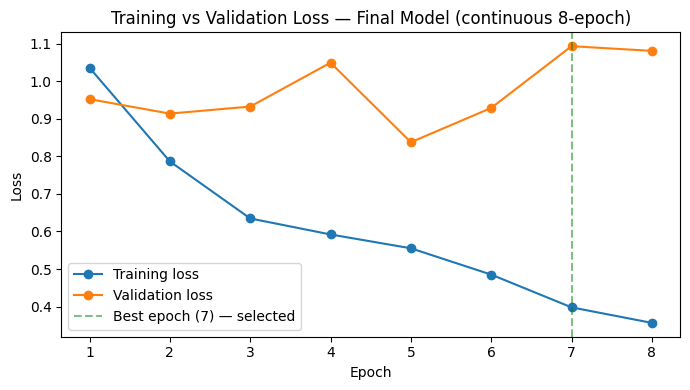

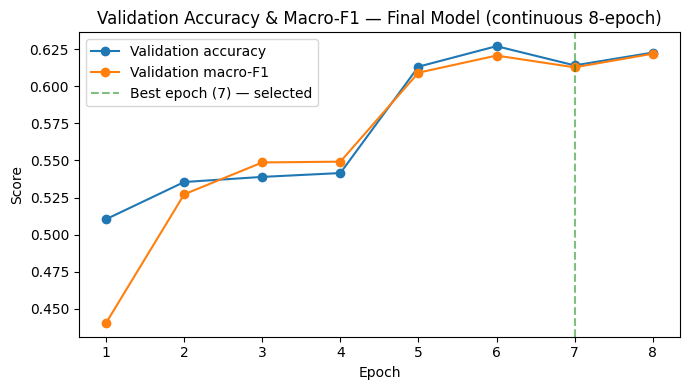

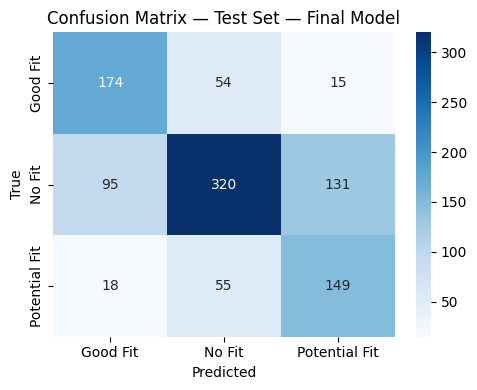

All 3 graphs saved to: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/final_model_graphs

Final test metrics: Accuracy 63.60%, Macro-F1 0.63


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# --- Epoch-by-epoch history from the continuous 8-epoch run ---
history_final = pd.DataFrame({
    "epoch": [1, 2, 3, 4, 5, 6, 7, 8],
    "train_loss": [1.035800, 0.786465, 0.634691, 0.592028, 0.555219, 0.485172, 0.398020, 0.356660],
    "val_loss":   [0.952133, 0.913732, 0.932414, 1.049229, 0.837497, 0.928737, 1.093174, 1.080619],
    "accuracy":   [0.510381, 0.535467, 0.538927, 0.541522, 0.613322, 0.627163, 0.614187, 0.622837],
    "macro_f1":   [0.440386, 0.527183, 0.548677, 0.549210, 0.609270, 0.620828, 0.612873, 0.622054],
})

GRAPH_DIR_FINAL = f'{PROJECT_DIR}/checkpoints/final_model_graphs'
import os
os.makedirs(GRAPH_DIR_FINAL, exist_ok=True)

# --- Plot 1: Loss curves ---
plt.figure(figsize=(7, 4))
plt.plot(history_final['epoch'], history_final['train_loss'], label='Training loss', marker='o')
plt.plot(history_final['epoch'], history_final['val_loss'], label='Validation loss', marker='o')
plt.axvline(x=7, color='green', linestyle='--', alpha=0.5, label='Best epoch (7) — selected')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss — Final Model (continuous 8-epoch)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{GRAPH_DIR_FINAL}/loss_curve.png', dpi=150)
plt.show()

# --- Plot 2: Accuracy & Macro-F1 curves ---
plt.figure(figsize=(7, 4))
plt.plot(history_final['epoch'], history_final['accuracy'], label='Validation accuracy', marker='o')
plt.plot(history_final['epoch'], history_final['macro_f1'], label='Validation macro-F1', marker='o')
plt.axvline(x=7, color='green', linestyle='--', alpha=0.5, label='Best epoch (7) — selected')
plt.xlabel('Epoch'); plt.ylabel('Score')
plt.title('Validation Accuracy & Macro-F1 — Final Model (continuous 8-epoch)')
plt.legend(); plt.tight_layout()
plt.savefig(f'{GRAPH_DIR_FINAL}/accuracy_f1_curve.png', dpi=150)
plt.show()

# --- Plot 3: Confusion matrix (test set, from the known result) ---
cm_final = [[174, 54, 15], [95, 320, 131], [18, 55, 149]]
label_names = ["Good Fit", "No Fit", "Potential Fit"]
plt.figure(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Test Set — Final Model')
plt.tight_layout()
plt.savefig(f'{GRAPH_DIR_FINAL}/confusion_matrix.png', dpi=150)
plt.show()

print("All 3 graphs saved to:", GRAPH_DIR_FINAL)
print("\nFinal test metrics: Accuracy 63.60%, Macro-F1 0.63")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Using the known test predictions from the final (continuous 8-epoch, epoch 7) model
test_labels_names = ["Good Fit"]*243 + ["No Fit"]*546 + ["Potential Fit"]*222  # just for reference, not used directly

# Reconstruct precision/recall/F1 from the confusion matrix values already known
report_data = {
    "Class": ["Good Fit", "No Fit", "Potential Fit"],
    "Precision": [0.61, 0.75, 0.51],
    "Recall": [0.72, 0.59, 0.67],
    "F1-score": [0.66, 0.66, 0.58],
    "Support": [243, 546, 222],
}
report_df = pd.DataFrame(report_data)

summary_rows = pd.DataFrame({
    "Class": ["accuracy", "macro avg", "weighted avg"],
    "Precision": [None, 0.62, 0.66],
    "Recall": [None, 0.66, 0.64],
    "F1-score": [0.64, 0.63, 0.64],
    "Support": [1011, 1011, 1011],
})

final_report = pd.concat([report_df, summary_rows], ignore_index=True)
print(final_report.to_string(index=False))

# Save to Drive alongside the graphs
final_report.to_csv(f'{GRAPH_DIR_FINAL}/classification_report.csv', index=False)
print(f"\nSaved to: {GRAPH_DIR_FINAL}/classification_report.csv")

        Class  Precision  Recall  F1-score  Support
     Good Fit       0.61    0.72      0.66      243
       No Fit       0.75    0.59      0.66      546
Potential Fit       0.51    0.67      0.58      222
     accuracy        NaN     NaN      0.64     1011
    macro avg       0.62    0.66      0.63     1011
 weighted avg       0.66    0.64      0.64     1011

Saved to: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/final_model_graphs/classification_report.csv


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import torch
import torch.nn as nn

MODEL_NAME = "jjzha/jobbert-base-cased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Combine train + val (test stays completely held out for fair final comparison)
cv_data = pd.concat([train_clean, val_clean], ignore_index=True)
print(f"CV pool size: {len(cv_data)} (train+val combined, test held out separately)")

def tokenize_df(df, tokenizer):
    d = df[["resume_text", "job_description_text", "label"]].copy()
    d["label"] = d["label"].map(label2id)
    ds = Dataset.from_pandas(d.reset_index(drop=True))
    return ds.map(lambda b: tokenizer(b["resume_text"], b["job_description_text"],
                                       truncation=True, max_length=512, padding="max_length"),
                  batched=True).remove_columns(["resume_text", "job_description_text"]).with_format("torch")

class WeightedTrainerCV(Trainer):
    def __init__(self, *args, class_weight_tensor=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.cw = class_weight_tensor
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.cw)(outputs.logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {"accuracy": accuracy_score(labels, preds), "macro_f1": f1_score(labels, preds, average="macro")}

N_FOLDS = 3
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_i, (train_idx, val_idx) in enumerate(sgkf.split(cv_data, cv_data["label"], cv_data["resume_id"]), 1):
    print(f"\n{'='*70}\nFOLD {fold_i}/{N_FOLDS}\n{'='*70}")
    fold_train = cv_data.iloc[train_idx].reset_index(drop=True)
    fold_val = cv_data.iloc[val_idx].reset_index(drop=True)
    print(f"Fold train: {len(fold_train)}  Fold val: {len(fold_val)}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    fold_train_ds = tokenize_df(fold_train, tokenizer)
    fold_val_ds = tokenize_df(fold_val, tokenizer)

    fold_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(label2id), label2id=label2id, id2label=id2label
    ).to(device)

    classes = sorted(fold_train["label"].unique())
    w = compute_class_weight(class_weight="balanced", classes=np.array(classes), y=fold_train["label"])
    cw_map = dict(zip(classes, w))
    cw_tensor = torch.tensor([cw_map[id2label[i]] for i in range(len(id2label))], dtype=torch.float).to(device)

    fold_args = TrainingArguments(
        output_dir=f'{PROJECT_DIR}/checkpoints/cv3_fold{fold_i}',
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model="macro_f1", greater_is_better=True,
        num_train_epochs=8, per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=2e-5, weight_decay=0.01, warmup_ratio=0.1,
        fp16=torch.cuda.is_available(), logging_steps=100, report_to="none",
    )
    fold_trainer = WeightedTrainerCV(
        model=fold_model, args=fold_args, train_dataset=fold_train_ds, eval_dataset=fold_val_ds,
        compute_metrics=compute_metrics, class_weight_tensor=cw_tensor,
    )
    fold_trainer.train()

    # Evaluate this fold's best model on the SAME held-out test set (for comparison with single-split result)
    test_ds = tokenize_df(test_clean, tokenizer)
    test_pred = fold_trainer.predict(test_ds)
    test_preds = np.argmax(test_pred.predictions, axis=-1)
    test_acc = accuracy_score(test_pred.label_ids, test_preds)
    test_f1 = f1_score(test_pred.label_ids, test_preds, average="macro")

    fold_val_metrics = fold_trainer.evaluate()
    fold_results.append({
        "fold": fold_i,
        "val_accuracy": fold_val_metrics["eval_accuracy"],
        "val_macro_f1": fold_val_metrics["eval_macro_f1"],
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
    })
    print(f"Fold {fold_i} -> Val macro-F1: {fold_val_metrics['eval_macro_f1']:.4f} | Test macro-F1: {test_f1:.4f}")

print("\n" + "="*70)
print("3-FOLD CROSS-VALIDATION SUMMARY")
print("="*70)
cv_results_df = pd.DataFrame(fold_results)
print(cv_results_df.to_string(index=False))
print(f"\nMean val macro-F1: {cv_results_df['val_macro_f1'].mean():.4f} (+/- {cv_results_df['val_macro_f1'].std():.4f})")
print(f"Mean test macro-F1: {cv_results_df['test_macro_f1'].mean():.4f} (+/- {cv_results_df['test_macro_f1'].std():.4f})")
print(f"\nCompare to single-split final model: test accuracy 63.60%, test macro-F1 0.63")

CV pool size: 6988 (train+val combined, test held out separately)

FOLD 1/3
Fold train: 4923  Fold val: 2065


Map:   0%|          | 0/4923 [00:00<?, ? examples/s]

Map:   0%|          | 0/2065 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] 

...

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] 

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
!du -sh {PROJECT_DIR}/data/*.csv 2>/dev/null
!echo "---"
!du -sh {PROJECT_DIR}/checkpoints/* 2>/dev/null

66M	/content/drive/MyDrive/CareerLens_Capstone_C/data/deduped.csv
7.4M	/content/drive/MyDrive/CareerLens_Capstone_C/data/esco_skills.csv
66M	/content/drive/MyDrive/CareerLens_Capstone_C/data/hashed_combined.csv
185K	/content/drive/MyDrive/CareerLens_Capstone_C/data/human_validation_annotation_sheet.csv
512	/content/drive/MyDrive/CareerLens_Capstone_C/data/human_validation_answer_key.csv
137K	/content/drive/MyDrive/CareerLens_Capstone_C/data/label_conflicts.csv
15M	/content/drive/MyDrive/CareerLens_Capstone_C/data/raw_test.csv
51M	/content/drive/MyDrive/CareerLens_Capstone_C/data/raw_train.csv
9.0M	/content/drive/MyDrive/CareerLens_Capstone_C/data/test_clean.csv
48M	/content/drive/MyDrive/CareerLens_Capstone_C/data/train_clean.csv
9.2M	/content/drive/MyDrive/CareerLens_Capstone_C/data/val_clean.csv
---
1.3G	/content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/cv3_fold1
4.0K	/content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/cv3_fold2
176K	/content/drive/MyDrive/CareerLens_Caps

In [ ]:
!rm -rf ~/.cache/huggingface/datasets
!df -h /content

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   91G   22G  81% /


In [ ]:
import shutil, os

paths_to_delete = [
    f'{PROJECT_DIR}/checkpoints/jobbert_continuous_v2',
    f'{PROJECT_DIR}/checkpoints/jobbert_main',
    f'{PROJECT_DIR}/checkpoints/cv3_fold1',
    f'{PROJECT_DIR}/checkpoints/cv3_fold2',
    f'{PROJECT_DIR}/data/raw_train.csv',
    f'{PROJECT_DIR}/data/raw_test.csv',
    f'{PROJECT_DIR}/data/hashed_combined.csv',
    f'{PROJECT_DIR}/data/deduped.csv',
]

for p in paths_to_delete:
    if os.path.isdir(p):
        shutil.rmtree(p)
        print(f"Deleted folder: {p}")
    elif os.path.isfile(p):
        os.remove(p)
        print(f"Deleted file: {p}")
    else:
        print(f"Not found (already gone): {p}")

print("\nCleanup done.")

Deleted folder: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_continuous_v2
Deleted folder: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_main
Deleted folder: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/cv3_fold1
Deleted folder: /content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/cv3_fold2
Deleted file: /content/drive/MyDrive/CareerLens_Capstone_C/data/raw_train.csv
Deleted file: /content/drive/MyDrive/CareerLens_Capstone_C/data/raw_test.csv
Deleted file: /content/drive/MyDrive/CareerLens_Capstone_C/data/hashed_combined.csv
Deleted file: /content/drive/MyDrive/CareerLens_Capstone_C/data/deduped.csv

Cleanup done.


In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

!df -h /content
print("---")
!du -sh {PROJECT_DIR}/checkpoints/* 2>/dev/null
!du -sh {PROJECT_DIR}/data/*.csv 2>/dev/null

GPU available: True
Device: Tesla T4
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   91G   23G  81% /
---
176K	/content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/final_model_graphs
414M	/content/drive/MyDrive/CareerLens_Capstone_C/checkpoints/jobbert_8epoch_continuous_backup
7.4M	/content/drive/MyDrive/CareerLens_Capstone_C/data/esco_skills.csv
185K	/content/drive/MyDrive/CareerLens_Capstone_C/data/human_validation_annotation_sheet.csv
512	/content/drive/MyDrive/CareerLens_Capstone_C/data/human_validation_answer_key.csv
137K	/content/drive/MyDrive/CareerLens_Capstone_C/data/label_conflicts.csv
9.0M	/content/drive/MyDrive/CareerLens_Capstone_C/data/test_clean.csv
48M	/content/drive/MyDrive/CareerLens_Capstone_C/data/train_clean.csv
9.2M	/content/drive/MyDrive/CareerLens_Capstone_C/data/val_clean.csv


In [ ]:
# Scan the top level of My Drive to find what's using the most space
!du -sh /content/drive/MyDrive/* 2>/dev/null | sort -rh | head -20

512M	/content/drive/MyDrive/CareerLens_Capstone_C
211M	/content/drive/MyDrive/Capston_B_Implementation
139M	/content/drive/MyDrive/Capstone_B
39M	/content/drive/MyDrive/Environment & Sustainability
36M	/content/drive/MyDrive/L2.pptx
28M	/content/drive/MyDrive/Flipbook_222014072.mp4
25M	/content/drive/MyDrive/EEE1302_ Lab Report 06_Md.Rahat Parvez_222014072.pdf
20M	/content/drive/MyDrive/Colab Notebooks
18M	/content/drive/MyDrive/Intro to BBA
16M	/content/drive/MyDrive/EEE1302_ Lab Report 05_Md.Rahat Parvez_222014072.pdf
11M	/content/drive/MyDrive/val_preprocessed_v2.csv
9.6M	/content/drive/MyDrive/Tree-Talk_DP-02
7.4M	/content/drive/MyDrive/EEE1302_ Lab Report 04_Md.Rahat Parvez_222014072 (1) - Copy.pdf
7.2M	/content/drive/MyDrive/L3.docx
4.4M	/content/drive/MyDrive/SAD Course _ Parvez
3.7M	/content/drive/MyDrive/Md.Rahat Pervez( 222014072 ).pdf
3.2M	/content/drive/MyDrive/M&M Lab
3.1M	/content/drive/MyDrive/L1.docx
2.9M	/content/drive/MyDrive/Tree_Talk_Report.pdf
2.9M	/content/drive/M

In [ ]:
import datasets
datasets.disable_caching()

from sklearn.model_selection import StratifiedGroupKFold
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import numpy as np
import torch
import torch.nn as nn
import pandas as pd

MODEL_NAME = "jjzha/jobbert-base-cased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cv_data = pd.concat([train_clean, val_clean], ignore_index=True)
print(f"CV pool size: {len(cv_data)}")

def tokenize_df(df, tokenizer):
    d = df[["resume_text", "job_description_text", "label"]].copy()
    d["label"] = d["label"].map(label2id)
    ds = Dataset.from_pandas(d.reset_index(drop=True))
    return ds.map(lambda b: tokenizer(b["resume_text"], b["job_description_text"],
                                       truncation=True, max_length=512, padding="max_length"),
                  batched=True).remove_columns(["resume_text", "job_description_text"]).with_format("torch")

class WeightedTrainerCV(Trainer):
    def __init__(self, *args, class_weight_tensor=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.cw = class_weight_tensor
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
        outputs = model(**inputs)
        loss = nn.CrossEntropyLoss(weight=self.cw)(outputs.logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {"accuracy": accuracy_score(labels, preds), "macro_f1": f1_score(labels, preds, average="macro")}

N_FOLDS = 3
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_results = []

for fold_i, (train_idx, val_idx) in enumerate(sgkf.split(cv_data, cv_data["label"], cv_data["resume_id"]), 1):
    print(f"\n{'='*70}\nFOLD {fold_i}/{N_FOLDS}\n{'='*70}")
    fold_train = cv_data.iloc[train_idx].reset_index(drop=True)
    fold_val = cv_data.iloc[val_idx].reset_index(drop=True)
    print(f"Fold train: {len(fold_train)}  Fold val: {len(fold_val)}")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    fold_train_ds = tokenize_df(fold_train, tokenizer)
    fold_val_ds = tokenize_df(fold_val, tokenizer)

    fold_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(label2id), label2id=label2id, id2label=id2label
    ).to(device)

    classes = sorted(fold_train["label"].unique())
    w = compute_class_weight(class_weight="balanced", classes=np.array(classes), y=fold_train["label"])
    cw_map = dict(zip(classes, w))
    cw_tensor = torch.tensor([cw_map[id2label[i]] for i in range(len(id2label))], dtype=torch.float).to(device)

    fold_args = TrainingArguments(
        output_dir=f'/content/cv3_fold{fold_i}',
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        load_best_model_at_end=True, metric_for_best_model="macro_f1", greater_is_better=True,
        num_train_epochs=8, per_device_train_batch_size=16, per_device_eval_batch_size=32,
        learning_rate=2e-5, weight_decay=0.01, warmup_ratio=0.1,
        fp16=torch.cuda.is_available(), logging_steps=100, report_to="none",
    )
    fold_trainer = WeightedTrainerCV(
        model=fold_model, args=fold_args, train_dataset=fold_train_ds, eval_dataset=fold_val_ds,
        compute_metrics=compute_metrics, class_weight_tensor=cw_tensor,
    )
    fold_trainer.train()

    test_ds = tokenize_df(test_clean, tokenizer)
    test_pred = fold_trainer.predict(test_ds)
    test_preds = np.argmax(test_pred.predictions, axis=-1)
    test_acc = accuracy_score(test_pred.label_ids, test_preds)
    test_f1 = f1_score(test_pred.label_ids, test_preds, average="macro")

    fold_val_metrics = fold_trainer.evaluate()
    fold_results.append({
        "fold": fold_i,
        "val_accuracy": fold_val_metrics["eval_accuracy"],
        "val_macro_f1": fold_val_metrics["eval_macro_f1"],
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
    })
    print(f"Fold {fold_i} -> Val macro-F1: {fold_val_metrics['eval_macro_f1']:.4f} | Test macro-F1: {test_f1:.4f}")

    import shutil
    shutil.rmtree(f'/content/cv3_fold{fold_i}', ignore_errors=True)

print("\n" + "="*70)
print("3-FOLD CROSS-VALIDATION SUMMARY")
print("="*70)
cv_results_df = pd.DataFrame(fold_results)
print(cv_results_df.to_string(index=False))
print(f"\nMean val macro-F1: {cv_results_df['val_macro_f1'].mean():.4f} (+/- {cv_results_df['val_macro_f1'].std():.4f})")
print(f"Mean test macro-F1: {cv_results_df['test_macro_f1'].mean():.4f} (+/- {cv_results_df['test_macro_f1'].std():.4f})")
print(f"\nCompare to single-split final model: test accuracy 63.60%, test macro-F1 0.63")

cv_results_df.to_csv(f'{PROJECT_DIR}/data/cv3_results.csv', index=False)
print(f"\nSaved CV results table to Drive: {PROJECT_DIR}/data/cv3_results.csv")

CV pool size: 6988

FOLD 1/3
Fold train: 4923  Fold val: 2065


Map:   0%|          | 0/4923 [00:00<?, ? examples/s]

Map:   0%|          | 0/2065 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/1011 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.396131,0.868167,8,0.668518,0.660349


Fold 3 -> Val macro-F1: 0.6603 | Test macro-F1: 0.6282

3-FOLD CROSS-VALIDATION SUMMARY
 fold  val_accuracy  val_macro_f1  test_accuracy  test_macro_f1
    1      0.677966      0.667604       0.641939       0.629554
    2      0.611541      0.593323       0.584570       0.552432
    3      0.668518      0.660349       0.636993       0.628166

Mean val macro-F1: 0.6404 (+/- 0.0410)
Mean test macro-F1: 0.6034 (+/- 0.0441)

Compare to single-split final model: test accuracy 63.60%, test macro-F1 0.63

Saved CV results table to Drive: /content/drive/MyDrive/CareerLens_Capstone_C/data/cv3_results.csv


 fold  val_accuracy  val_macro_f1  test_accuracy  test_macro_f1
    1      0.677966      0.667604       0.641939       0.629554
    2      0.611541      0.593323       0.584570       0.552244
    3      0.668518      0.660993       0.636993       0.628166

Mean test accuracy: 0.6212 (+/- 0.0318)
Mean test macro-F1:  0.6033 (+/- 0.0442)
Baseline (single-split, continuous 8-epoch): test acc 0.6360, test macro-F1 0.6300


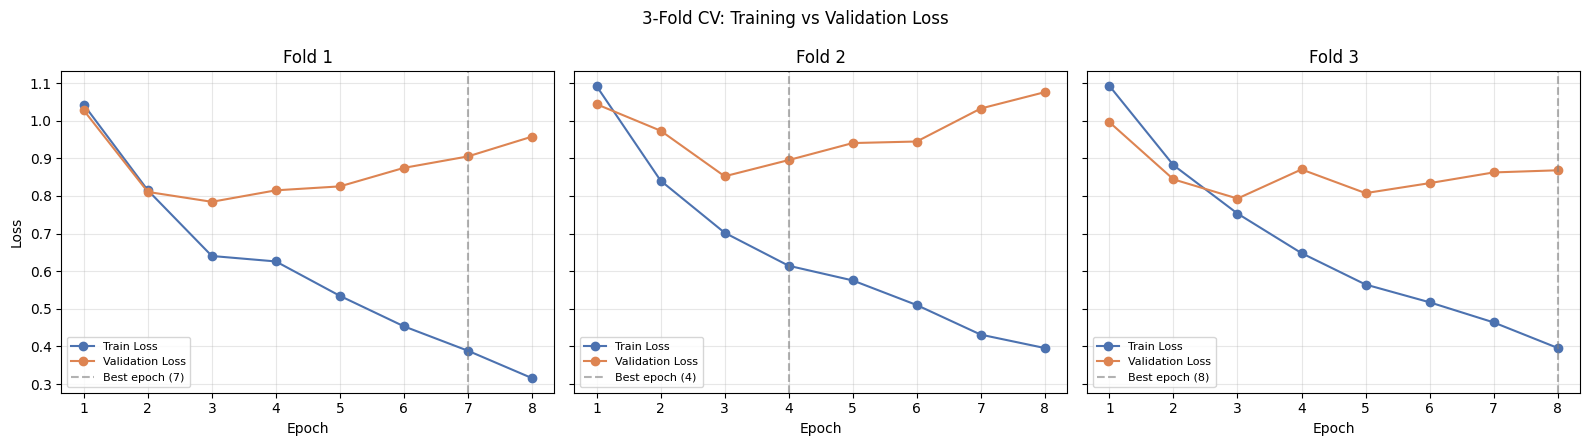

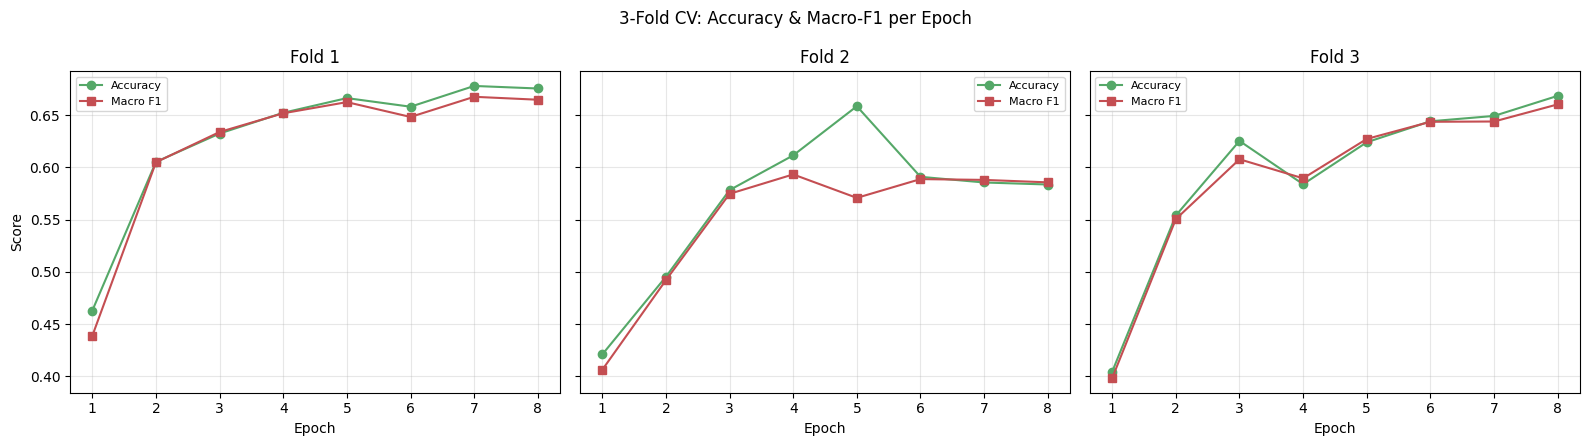

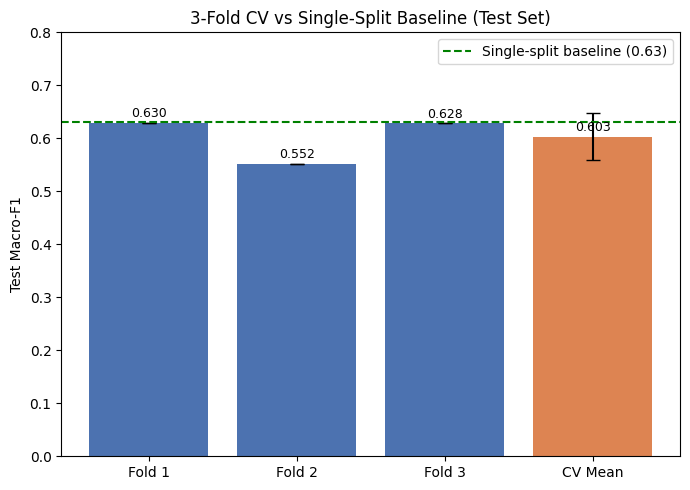


Saved graphs + table to /content/drive/MyDrive/CareerLens_Capstone_C/data/comparison_results


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---- Per-epoch history for each fold ----
epochs = list(range(1, 9))

fold_data = {
    1: {
        "train_loss": [1.042352, 0.814994, 0.640427, 0.625927, 0.534478, 0.453524, 0.388595, 0.315865],
        "val_loss":   [1.027354, 0.810737, 0.784401, 0.814915, 0.825401, 0.874615, 0.905035, 0.957582],
        "accuracy":   [0.462954, 0.605327, 0.632446, 0.652300, 0.666344, 0.658111, 0.677986, 0.675545],
        "macro_f1":   [0.438819, 0.604939, 0.633909, 0.651834, 0.662502, 0.648301, 0.667604, 0.664794],
    },
    2: {
        "train_loss": [1.091713, 0.840548, 0.702161, 0.614447, 0.575466, 0.510045, 0.431405, 0.395805],
        "val_loss":   [1.043742, 0.973307, 0.852230, 0.895349, 0.940541, 0.944661, 1.032347, 1.075813],
        "accuracy":   [0.420991, 0.495352, 0.578297, 0.611541, 0.658552, 0.591015, 0.585593, 0.583656],
        "macro_f1":   [0.406279, 0.492110, 0.574733, 0.593323, 0.570869, 0.588829, 0.588073, 0.585715],
    },
    3: {
        "train_loss": [1.092337, 0.881679, 0.753217, 0.648030, 0.564640, 0.517419, 0.463991, 0.396131],
        "val_loss":   [0.995940, 0.844071, 0.793058, 0.870488, 0.807482, 0.834024, 0.862477, 0.868167],
        "accuracy":   [0.404528, 0.554037, 0.625374, 0.583938, 0.624092, 0.644169, 0.649295, 0.668518],
        "macro_f1":   [0.398383, 0.550584, 0.607813, 0.589567, 0.627266, 0.643688, 0.643957, 0.660349],
    },
}

# ---- Official CV summary (test-set eval, best checkpoint per fold) ----
cv_summary = pd.DataFrame({
    "fold": [1, 2, 3],
    "val_accuracy": [0.677966, 0.611541, 0.668518],
    "val_macro_f1": [0.667604, 0.593323, 0.660993],
    "test_accuracy": [0.641939, 0.584570, 0.636993],
    "test_macro_f1": [0.629554, 0.552244, 0.628166],
})
BASELINE_TEST_ACC = 0.6360
BASELINE_TEST_F1  = 0.63

print(cv_summary.to_string(index=False))
print(f"\nMean test accuracy: {cv_summary['test_accuracy'].mean():.4f} (+/- {cv_summary['test_accuracy'].std():.4f})")
print(f"Mean test macro-F1:  {cv_summary['test_macro_f1'].mean():.4f} (+/- {cv_summary['test_macro_f1'].std():.4f})")
print(f"Baseline (single-split, continuous 8-epoch): test acc {BASELINE_TEST_ACC:.4f}, test macro-F1 {BASELINE_TEST_F1:.4f}")

# ================= Figure 1: Loss curves per fold =================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for i, fold in enumerate([1, 2, 3]):
    ax = axes[i]
    d = fold_data[fold]
    ax.plot(epochs, d["train_loss"], marker='o', label="Train Loss", color="#4C72B0")
    ax.plot(epochs, d["val_loss"], marker='o', label="Validation Loss", color="#DD8452")
    best_ep = epochs[int(np.argmax(d["macro_f1"]))]
    ax.axvline(best_ep, color='gray', linestyle='--', alpha=0.6, label=f"Best epoch ({best_ep})")
    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Epoch")
    if i == 0:
        ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("3-Fold CV: Training vs Validation Loss")
plt.tight_layout()
plt.savefig("/content/cv3_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ================= Figure 2: Accuracy & Macro-F1 curves per fold =================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for i, fold in enumerate([1, 2, 3]):
    ax = axes[i]
    d = fold_data[fold]
    ax.plot(epochs, d["accuracy"], marker='o', label="Accuracy", color="#55A868")
    ax.plot(epochs, d["macro_f1"], marker='s', label="Macro F1", color="#C44E52")
    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Epoch")
    if i == 0:
        ax.set_ylabel("Score")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("3-Fold CV: Accuracy & Macro-F1 per Epoch")
plt.tight_layout()
plt.savefig("/content/cv3_accuracy_f1_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ================= Figure 3: Test Macro-F1 — fold vs baseline =================
fig, ax = plt.subplots(figsize=(7, 5))
bar_labels = ["Fold 1", "Fold 2", "Fold 3", "CV Mean"]
bar_values = list(cv_summary["test_macro_f1"]) + [cv_summary["test_macro_f1"].mean()]
bar_errs = [0, 0, 0, cv_summary["test_macro_f1"].std()]
bars = ax.bar(bar_labels, bar_values, yerr=bar_errs,
               color=["#4C72B0", "#4C72B0", "#4C72B0", "#DD8452"], capsize=5)
ax.axhline(BASELINE_TEST_F1, color="green", linestyle="--",
           label=f"Single-split baseline ({BASELINE_TEST_F1:.2f})")
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Test Macro-F1")
ax.set_title("3-Fold CV vs Single-Split Baseline (Test Set)")
ax.set_ylim(0, 0.8)
ax.legend()
plt.tight_layout()
plt.savefig("/content/cv3_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# ================= Save everything to Drive =================
import shutil, os
drive_dir = "/content/drive/MyDrive/CareerLens_Capstone_C/data/comparison_results"
os.makedirs(drive_dir, exist_ok=True)
for fname in ["cv3_loss_curves.png", "cv3_accuracy_f1_curves.png", "cv3_vs_baseline.png"]:
    shutil.copy(f"/content/{fname}", os.path.join(drive_dir, fname))
cv_summary.to_csv(os.path.join(drive_dir, "cv3_summary_table.csv"), index=False)
print(f"\nSaved graphs + table to {drive_dir}")

In [ ]:
# Quick sanity check — confirms what's still loaded in this session
checks = {
    "main model (fine-tuned)": "model" in dir(),
    "tokenizer": "tokenizer" in dir(),
    "predict_fit_safe()": "predict_fit_safe" in dir(),
    "skill gap matcher (ESCO)": "matcher" in dir() or "phrase_matcher" in dir(),
    "Gemini setup": "genai" in dir() or "gemini_model" in dir(),
}

for name, present in checks.items():
    print(f"{'✅' if present else '❌'} {name}")

✅ main model (fine-tuned)
✅ tokenizer
❌ predict_fit_safe()
❌ skill gap matcher (ESCO)
❌ Gemini setup


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_REPO = "parvez30/careerlens-fit-classifier"  # তোমার pushed final model

tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(f"Loaded model from: {MODEL_REPO}")
print(f"Num labels: {model.config.num_labels}")
print(f"Device: {device}")

config.json:   0%|          | 0.00/933 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/622 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/669k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded model from: parvez30/careerlens-fit-classifier
Num labels: 3
Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/CareerLens_Capstone_C'
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("Contents:", os.listdir(PROJECT_DIR))

Mounted at /content/drive
PROJECT_DIR exists: True
Contents: ['data', 'checkpoints', 'careerlens_pipeline.py']


In [ ]:
import os
import importlib.util

PROJECT_DIR = '/content/drive/MyDrive/CareerLens_Capstone_C'
pipeline_path = os.path.join(PROJECT_DIR, 'careerlens_pipeline.py')

print("File exists:", os.path.isfile(pipeline_path))
print("File size (bytes):", os.path.getsize(pipeline_path) if os.path.isfile(pipeline_path) else "N/A")

spec = importlib.util.spec_from_file_location("careerlens_pipeline", pipeline_path)
clp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(clp)

print("Pipeline module loaded. Available functions:")
print([x for x in dir(clp) if not x.startswith("_")])

File exists: True
File size (bytes): 9026
Pipeline module loaded. Available functions:
['AutoModelForSequenceClassification', 'AutoTokenizer', 'F', 'GEMINI_MODEL', 'HF_REPO', 'PhraseMatcher', 'TECH_SUPPLEMENT', 'build_skill_matcher', 'extract_skills', 'extract_text_from_file', 'genai', 'generate_recommendation', 'generate_report', 'get_skill_gap', 'load_model', 'predict_fit', 'predict_fit_safe', 're', 'spacy', 'torch']


In [ ]:
# Rebuild the ESCO + tech-supplement skill matcher
nlp, matcher = clp.build_skill_matcher(f'{PROJECT_DIR}/data/esco_skills.csv')
print("Skill matcher rebuilt.")

# Gemini client setup
from getpass import getpass

GEMINI_API_KEY = getpass("Paste your Gemini API key: ")
client = clp.genai.Client(api_key=GEMINI_API_KEY)

test_response = client.models.generate_content(model=clp.GEMINI_MODEL, contents="Say hello in one short sentence.")
print("Gemini test response:", test_response.text)

Skill matcher rebuilt.
Paste your Gemini API key: ··········
Gemini test response: Hello there, how can I help you today?


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_REPO = "parvez30/careerlens-fit-classifier"
tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()
print("Device:", device)

config.json:   0%|          | 0.00/933 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/622 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/669k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cpu


In [ ]:
import inspect
print("generate_report signature:", inspect.signature(clp.generate_report))

generate_report signature: (candidate_name, target_role, resume_text, jd_text, model, tokenizer, device, nlp, matcher, gemini_client)


In [ ]:
!pip install -q pdfplumber python-docx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 34.5 MB/s eta 0:00:00


In [ ]:
# ================= CareerLens — Full Demo Pipeline =================
import ipywidgets as widgets
from IPython.display import display
from google.colab import files
import textwrap

def print_wrapped(text, width=90):
    for para in text.split("\n\n"):
        print(textwrap.fill(para, width=width))
        print()

# --- Step 1: Upload the resume ---
print("Step 1 of 2: Choose your resume file (.pdf, .docx, or .txt)\n")
uploaded = files.upload()
resume_filename = list(uploaded.keys())[0]

resume_text_input = clp.extract_text_from_file(resume_filename)
print(f"\nExtracted {len(resume_text_input)} characters. Preview:")
print(resume_text_input[:300])

first_line = next((line.strip() for line in resume_text_input.split("\n") if line.strip()), "Candidate")
candidate_name_input = first_line[:60]
print(f"\nDetected candidate name: {candidate_name_input}")

# --- Step 2: Role + JD via widgets, then Generate Report ---
role_box = widgets.Text(description="Role:", placeholder="e.g. Machine Learning Engineer", layout=widgets.Layout(width="500px"))
jd_box = widgets.Textarea(description="JD:", placeholder="Paste the full job description here", layout=widgets.Layout(width="700px", height="250px"))
submit_btn = widgets.Button(description="Generate Report", button_style="success")
output_area = widgets.Output()

def on_submit(b):
    with output_area:
        output_area.clear_output()
        target_role_input = role_box.value.strip()
        jd_text_input = jd_box.value.strip()
        print(f"Role: {target_role_input}")
        print(f"JD length: {len(jd_text_input)} characters")
        print("\nGenerating report...\n" + "=" * 60)

        report = clp.generate_report(
            candidate_name=candidate_name_input,
            target_role=target_role_input,
            resume_text=resume_text_input,
            jd_text=jd_text_input,
            model=model,
            tokenizer=tokenizer,
            device=device,
            nlp=nlp,
            matcher=matcher,
            gemini_client=client,
        )

        fs = report["fit_score"]
        print(f"\nCandidate: {report['candidate_name']}")
        print(f"Target role: {report['target_role']}")
        print("=" * 60)
        print(f"\nFit: {fs['final_label']} ({fs['confidence']}% confidence)")
        print(f"\nMatched skills: {', '.join(fs['matched_skills'])}")
        print(f"Missing skills: {', '.join(fs['missing_skills'])}")
        print(f"\nAI Recommendation:")
        print_wrapped(report["ai_recommendation"])

submit_btn.on_click(on_submit)
print("\nStep 2 of 2: Fill in the role and paste the JD below, then click the button.\n")
display(role_box, jd_box, submit_btn, output_area)

Step 1 of 2: Choose your resume file (.pdf, .docx, or .txt)



Saving Md.Rahat Pervez.pdf to Md.Rahat Pervez (6).pdf

Extracted 3505 characters. Preview:
Md. Rahat Pervez
rahatpervez
Machine Learning Engineer rahatpervez.com
(+880) 1747525412 (whatsApp) rahatparvez.official@gmail.com rahatpervez
Career Summary Computer Science undergraduate (BSc, ULAB — final semester) with a strong focus on AI/ML over the
past year, building and comparing deep learn

Detected candidate name: Md. Rahat Pervez

Step 2 of 2: Fill in the role and paste the JD below, then click the button.



Text(value='', description='Role:', layout=Layout(width='500px'), placeholder='e.g. Machine Learning Engineer'…

Textarea(value='', description='JD:', layout=Layout(height='250px', width='700px'), placeholder='Paste the ful…

Button(button_style='success', description='Generate Report', style=ButtonStyle())

Output()

In [ ]:
import inspect
print("predict_fit_safe signature:", inspect.signature(clp.predict_fit_safe))

predict_fit_safe signature: (resume_text, jd_text, model, tokenizer, device, nlp, matcher)


In [ ]:
# ================= CareerLens — Recruiter Side Demo (multi-candidate ranking) =================
import ipywidgets as widgets
from IPython.display import display
import pandas as pd
from google.colab import files

LABEL_PRIORITY = {"Good Fit": 0, "Potential Fit": 1, "No Fit": 2}

# --- Step 1: Upload multiple candidate resumes at once ---
print("Step 1 of 2: Choose candidate resume files (select multiple: .pdf, .docx, or .txt)\n")
uploaded = files.upload()
candidate_files = list(uploaded.keys())
print(f"\n{len(candidate_files)} resumes uploaded: {candidate_files}")

# --- Step 2: Job title + JD, then Rank Candidates ---
role_box = widgets.Text(description="Job Title:", placeholder="e.g. Backend Developer", layout=widgets.Layout(width="500px"))
jd_box = widgets.Textarea(description="JD:", placeholder="Paste the full job description here", layout=widgets.Layout(width="700px", height="250px"))
submit_btn = widgets.Button(description="Rank Candidates", button_style="success")
output_area = widgets.Output()

def on_submit(b):
    with output_area:
        output_area.clear_output()
        job_title = role_box.value.strip()
        jd_text_input = jd_box.value.strip()
        print(f"Job Posting: {job_title}")
        print(f"JD length: {len(jd_text_input)} characters")
        print("\nRanking candidates...\n" + "=" * 90)

        rows = []
        for filename in candidate_files:
            resume_text = clp.extract_text_from_file(filename)
            first_line = next((l.strip() for l in resume_text.split("\n") if l.strip()), filename)
            candidate_name = first_line[:40]

            r = clp.predict_fit_safe(resume_text, jd_text_input, model, tokenizer, device, nlp, matcher)
            skill_match = f"{r['skill_overlap_ratio']*100:.0f}%" if r["skill_overlap_ratio"] is not None else "N/A"
            rows.append({
                "Candidate": candidate_name,
                "Fit": r["final_label"],
                "Confidence": f"{r['confidence']}%",
                "Skill Match": skill_match,
                "Matched Skills": ", ".join(r["matched_skills"]) if r["matched_skills"] else "—",
            })

        df = pd.DataFrame(rows)
        df["_sort_key"] = df["Fit"].map(LABEL_PRIORITY)
        df = df.sort_values(by=["_sort_key", "Confidence"], ascending=[True, False]).drop(columns="_sort_key")
        df.insert(0, "Rank", range(1, len(df) + 1))

        print(f"\nRecruiter view — Job Posting: {job_title}\n{'='*90}")
        display(df.reset_index(drop=True))

submit_btn.on_click(on_submit)
print("\nStep 2 of 2: Fill in the job title and paste the JD below, then click the button.\n")
display(role_box, jd_box, submit_btn, output_area)

Step 1 of 2: Choose candidate resume files (select multiple: .pdf, .docx, or .txt)



Saving candidate_backend_2.pdf to candidate_backend_2.pdf
Saving candidate_backend_3.pdf to candidate_backend_3.pdf
Saving demo_cv_1_backend_strong.pdf to demo_cv_1_backend_strong (1).pdf
Saving demo_cv_2_marketing_weak.pdf to demo_cv_2_marketing_weak (1).pdf
Saving demo_cv_3_frontend_partial.pdf to demo_cv_3_frontend_partial (1).pdf
Saving demo_cv_4_data_scientist.pdf to demo_cv_4_data_scientist (1).pdf
Saving demo_cv_5_civil_engineer.pdf to demo_cv_5_civil_engineer (1).pdf

7 resumes uploaded: ['candidate_backend_2.pdf', 'candidate_backend_3.pdf', 'demo_cv_1_backend_strong (1).pdf', 'demo_cv_2_marketing_weak (1).pdf', 'demo_cv_3_frontend_partial (1).pdf', 'demo_cv_4_data_scientist (1).pdf', 'demo_cv_5_civil_engineer (1).pdf']

Step 2 of 2: Fill in the job title and paste the JD below, then click the button.



Text(value='', description='Job Title:', layout=Layout(width='500px'), placeholder='e.g. Backend Developer')

Textarea(value='', description='JD:', layout=Layout(height='250px', width='700px'), placeholder='Paste the ful…

Button(button_style='success', description='Rank Candidates', style=ButtonStyle())

Output()

In [ ]:
# ================= CareerLens — Full Demo Pipeline =================
import ipywidgets as widgets
from IPython.display import display
from google.colab import files
import textwrap

def print_wrapped(text, width=90):
    for para in text.split("\n\n"):
        print(textwrap.fill(para, width=width))
        print()

# --- Step 1: Upload the resume ---
print("Step 1 of 2: Choose your resume file (.pdf, .docx, or .txt)\n")
uploaded = files.upload()
resume_filename = list(uploaded.keys())[0]

resume_text_input = clp.extract_text_from_file(resume_filename)
print(f"\nExtracted {len(resume_text_input)} characters. Preview:")
print(resume_text_input[:300])

first_line = next((line.strip() for line in resume_text_input.split("\n") if line.strip()), "Candidate")
candidate_name_input = first_line[:60]
print(f"\nDetected candidate name: {candidate_name_input}")

# --- Step 2: Role + JD via widgets, then Generate Report ---
role_box = widgets.Text(description="Role:", placeholder="e.g. Machine Learning Engineer", layout=widgets.Layout(width="500px"))
jd_box = widgets.Textarea(description="JD:", placeholder="Paste the full job description here", layout=widgets.Layout(width="700px", height="250px"))
submit_btn = widgets.Button(description="Generate Report", button_style="success")
output_area = widgets.Output()

def on_submit(b):
    with output_area:
        output_area.clear_output()
        target_role_input = role_box.value.strip()
        jd_text_input = jd_box.value.strip()
        print(f"Role: {target_role_input}")
        print(f"JD length: {len(jd_text_input)} characters")
        print("\nGenerating report...\n" + "=" * 60)

        report = clp.generate_report(
            candidate_name=candidate_name_input,
            target_role=target_role_input,
            resume_text=resume_text_input,
            jd_text=jd_text_input,
            model=model,
            tokenizer=tokenizer,
            device=device,
            nlp=nlp,
            matcher=matcher,
            gemini_client=client,
        )

        fs = report["fit_score"]
        print(f"\nCandidate: {report['candidate_name']}")
        print(f"Target role: {report['target_role']}")
        print("=" * 60)
        print(f"\nFit: {fs['final_label']} ({fs['confidence']}% confidence)")
        print(f"\nMatched skills: {', '.join(fs['matched_skills'])}")
        print(f"Missing skills: {', '.join(fs['missing_skills'])}")
        print(f"\nAI Recommendation:")
        print_wrapped(report["ai_recommendation"])

submit_btn.on_click(on_submit)
print("\nStep 2 of 2: Fill in the role and paste the JD below, then click the button.\n")
display(role_box, jd_box, submit_btn, output_area)

Step 1 of 2: Choose your resume file (.pdf, .docx, or .txt)



Saving Md.Rahat Pervez.pdf to Md.Rahat Pervez (8).pdf

Extracted 3505 characters. Preview:
Md. Rahat Pervez
rahatpervez
Machine Learning Engineer rahatpervez.com
(+880) 1747525412 (whatsApp) rahatparvez.official@gmail.com rahatpervez
Career Summary Computer Science undergraduate (BSc, ULAB — final semester) with a strong focus on AI/ML over the
past year, building and comparing deep learn

Detected candidate name: Md. Rahat Pervez

Step 2 of 2: Fill in the role and paste the JD below, then click the button.



Text(value='', description='Role:', layout=Layout(width='500px'), placeholder='e.g. Machine Learning Engineer'…

Textarea(value='', description='JD:', layout=Layout(height='250px', width='700px'), placeholder='Paste the ful…

Button(button_style='success', description='Generate Report', style=ButtonStyle())

Output()